In [ ]:
import torch
import random
import pandas as pd
import io
import requests
from rdkit import Chem
from torch_geometric.data import Data

In [2]:
# We have 3 halogens x 3 positions = 9 classes
motifs = {
    # Chlorine
    0: ('[*]c1c(Cl)c(Cl)ccc1', 'Cl_Ortho'),
    1: ('[*]c1c(Cl)cc(Cl)cc1', 'Cl_Meta'),
    2: ('[*]c1c(Cl)ccc(Cl)c1', 'Cl_Para'),
    # Fluorine
    3: ('[*]c1c(F)c(F)ccc1', 'F_Ortho'),
    4: ('[*]c1c(F)cc(F)cc1', 'F_Meta'),
    5: ('[*]c1c(F)ccc(F)c1', 'F_Para'),
    # Bromine
    6: ('[*]c1c(Br)c(Br)ccc1', 'Br_Ortho'),
    7: ('[*]c1c(Br)cc(Br)cc1', 'Br_Meta'),
    8: ('[*]c1c(Br)ccc(Br)c1', 'Br_Para'),
}

In [3]:
def get_zinc_smiles(num_samples=1200):
    print(f"Downloading ZINC SMILES subset...")
    # We use a static URL to a clean ZINC subset (e.g., from a deeplychem repo or similar stable source)
    # Alternatively, we can use the AQSOL raw data URL.
    # Here I will use a direct raw GitHub link to a standard ZINC test set often used in benchmarking.
    url = "https://raw.githubusercontent.com/aspuru-guzik-group/chemical_vae/master/models/zinc_properties/250k_rndm_zinc_drugs_clean_3.csv"
    
    try:
        s = requests.get(url).content
        df = pd.read_csv(io.StringIO(s.decode('utf-8')))
        # The column is usually 'smiles' or similar. In this specific dataset it is likely the first column.
        # Let's clean it up.
        smiles_list = df.iloc[:, 0].tolist() # Assuming SMILES is 1st column
        print(f"Successfully loaded {len(smiles_list)} SMILES.")
        
        # Shuffle and pick needed amount
        random.shuffle(smiles_list)
        return smiles_list[:num_samples]
        
    except Exception as e:
        print(f"Error downloading SMILES: {e}")
        print("Falling back to dummy data for demonstration.")
        return ["CC1(C)CC(NC(=O)C2=CC=CO2)C1"] * num_samples

In [4]:
# ---------------------------------------------------------
# 3. GRAPH CONVERSION UTILS
# ---------------------------------------------------------
def get_one_hot_atom(atom_symbol):
    permitted_list = ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P']
    if atom_symbol not in permitted_list: atom_symbol = 'C'
    return [int(atom_symbol == s) for s in permitted_list]

In [5]:
def get_one_hot_bond(bond):
    bond_types = [Chem.rdchem.BondType.SINGLE, Chem.rdchem.BondType.DOUBLE,
                  Chem.rdchem.BondType.TRIPLE, Chem.rdchem.BondType.AROMATIC]
    b_type = bond.GetBondType()
    if b_type not in bond_types: b_type = Chem.rdchem.BondType.SINGLE
    return [int(b_type == bt) for bt in bond_types]

In [6]:
def attach_motif(scaffold_mol, motif_smiles):
    motif = Chem.MolFromSmiles(motif_smiles)
    valid_atoms = [a.GetIdx() for a in scaffold_mol.GetAtoms() 
                   if a.GetSymbol() == 'C' and a.GetTotalNumHs() > 0]
    
    if not valid_atoms: return None, None 

    attach_idx = random.choice(valid_atoms)
    combined = Chem.RWMol(scaffold_mol)
    motif_atom_map = {} 
    dummy_idx = -1
    
    for atom in motif.GetAtoms():
        if atom.GetAtomicNum() == 0: 
            dummy_idx = atom.GetIdx(); continue
        motif_atom_map[atom.GetIdx()] = combined.AddAtom(atom)

    for bond in motif.GetBonds():
        s, e = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        if s == dummy_idx or e == dummy_idx: continue
        combined.AddBond(motif_atom_map[s], motif_atom_map[e], bond.GetBondType())

    dummy_atom = motif.GetAtomWithIdx(dummy_idx)
    neighbor_idx = motif_atom_map[dummy_atom.GetNeighbors()[0].GetIdx()]
    combined.AddBond(attach_idx, neighbor_idx, Chem.BondType.SINGLE)
    
    scaffold_atom = combined.GetAtomWithIdx(attach_idx)
    scaffold_atom.SetNumExplicitHs(max(0, scaffold_atom.GetTotalNumHs() - 1))
    
    try: Chem.SanitizeMol(combined)
    except: return None, None

    return combined, list(motif_atom_map.values())

In [7]:
def mol_to_pyg(mol, label, motif_indices):
    x = torch.tensor([get_one_hot_atom(a.GetSymbol()) for a in mol.GetAtoms()], dtype=torch.float)
    
    edge_indices, edge_attrs = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        feat = get_one_hot_bond(bond)
        edge_indices += [[i, j], [j, i]]
        edge_attrs += [feat, feat]

    if not edge_indices: return None # Skip single atoms
    
    edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attrs, dtype=torch.float)
    
    mask = torch.zeros(mol.GetNumAtoms(), dtype=torch.long)
    mask[motif_indices] = 1
    
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, 
                y=torch.tensor([label], dtype=torch.long), explanation_mask=mask)

In [8]:
scaffold_smiles_list = get_zinc_smiles(num_samples=1500) # Get slightly more to buffer failures

Successfully loaded 249455 SMILES.


In [9]:
import torch
import random
import pandas as pd
import io
import requests
from rdkit import Chem
from rdkit.Chem import AllChem
from torch_geometric.data import Data

# ---------------------------------------------------------
# 1. SETUP NEW MOTIFS (with Methyl Linker)
# ---------------------------------------------------------
# The attachment point [*] is now on a Carbon (C) that is 
# attached to the ring (c1...). This creates the scaffold-C-ring structure.
motifs = {
    # Chlorine
    0: ('[*]Cc1c(Cl)c(Cl)ccc1', 'Cl_Ortho_Methyl'),
    1: ('[*]Cc1c(Cl)cc(Cl)cc1', 'Cl_Meta_Methyl'),
    2: ('[*]Cc1c(Cl)ccc(Cl)c1', 'Cl_Para_Methyl'),
    # Fluorine
    3: ('[*]Cc1c(F)c(F)ccc1', 'F_Ortho_Methyl'),
    4: ('[*]Cc1c(F)cc(F)cc1', 'F_Meta_Methyl'),
    5: ('[*]Cc1c(F)ccc(F)c1', 'F_Para_Methyl'),
    # Bromine
    6: ('[*]Cc1c(Br)c(Br)ccc1', 'Br_Ortho_Methyl'),
    7: ('[*]Cc1c(Br)cc(Br)cc1', 'Br_Meta_Methyl'),
    8: ('[*]Cc1c(Br)ccc(Br)c1', 'Br_Para_Methyl'),
}

# ---------------------------------------------------------
# 2. HELPER: Get Real SMILES (ZINC subset)
# ---------------------------------------------------------
def get_zinc_smiles(num_samples=2000):
    print(f"Downloading ZINC SMILES subset...")
    url = "https://raw.githubusercontent.com/aspuru-guzik-group/chemical_vae/master/models/zinc_properties/250k_rndm_zinc_drugs_clean_3.csv"
    
    try:
        s = requests.get(url).content
        df = pd.read_csv(io.StringIO(s.decode('utf-8')))
        smiles_list = df.iloc[:, 0].tolist() 
        print(f"Successfully loaded {len(smiles_list)} SMILES.")
        random.shuffle(smiles_list)
        return smiles_list[:num_samples]
    except Exception as e:
        print(f"Error downloading SMILES: {e}")
        # Fallback dummy data
        return ["CC1(C)CC(NC(=O)C2=CC=CO2)C1"] * num_samples

# ---------------------------------------------------------
# 3. ROBUST GRAPH EDITING
# ---------------------------------------------------------
def attach_motif(scaffold_smiles, motif_smiles):
    """
    Robustly attaches a motif by replacing a real Hydrogen atom.
    """
    # 1. Prepare Scaffold with Explicit Hydrogens
    scaffold = Chem.MolFromSmiles(scaffold_smiles)
    if scaffold is None: return None, None
    scaffold = Chem.AddHs(scaffold)

    # 2. Find a Valid C-H Pair to substitute
    valid_pairs = []
    for atom in scaffold.GetAtoms():
        if atom.GetSymbol() == 'C':
            for neighbor in atom.GetNeighbors():
                if neighbor.GetSymbol() == 'H':
                    valid_pairs.append((atom.GetIdx(), neighbor.GetIdx()))
    
    if not valid_pairs: return None, None
    c_idx, h_idx = random.choice(valid_pairs)
    
    # 3. Prepare Motif
    motif = Chem.MolFromSmiles(motif_smiles)
    dummy_idx = -1
    for atom in motif.GetAtoms():
        if atom.GetAtomicNum() == 0: dummy_idx = atom.GetIdx()
    
    # 4. Splicing
    combined = Chem.RWMol(scaffold)
    motif_idx_map = {}
    
    # Add Motif Atoms
    for atom in motif.GetAtoms():
        if atom.GetIdx() == dummy_idx: continue
        new_idx = combined.AddAtom(atom)
        motif_idx_map[atom.GetIdx()] = new_idx
        
    # Add Motif Internal Bonds
    for bond in motif.GetBonds():
        s, e = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        if s == dummy_idx or e == dummy_idx: continue
        combined.AddBond(motif_idx_map[s], motif_idx_map[e], bond.GetBondType())

    # Connect Scaffold to Motif
    # The neighbor of [*] is now the methyl carbon, which is correct.
    dummy_neighbor = motif.GetAtomWithIdx(dummy_idx).GetNeighbors()[0].GetIdx()
    motif_attach_point = motif_idx_map[dummy_neighbor]
    combined.AddBond(c_idx, motif_attach_point, Chem.BondType.SINGLE)
    
    # Remove the Hydrogen
    combined.RemoveAtom(h_idx)
    
    # 5. Index Correction for Ground Truth
    final_motif_indices = []
    for old_idx, new_idx in motif_idx_map.items():
        if new_idx > h_idx:
            final_motif_indices.append(new_idx - 1)
        else:
            final_motif_indices.append(new_idx)

    # 6. Final Cleanup
    try:
        Chem.SanitizeMol(combined)
        # We keep explicit Hs for the final graph to ensure the mask is perfectly aligned.
        return combined, final_motif_indices
        
    except:
        return None, None

# ---------------------------------------------------------
# 4. PYG CONVERSION
# ---------------------------------------------------------
def get_one_hot_atom(atom_symbol):
    # Added 'H' to the list as we are now keeping them
    permitted_list = ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P', 'H']
    if atom_symbol not in permitted_list: atom_symbol = 'C'
    return [int(atom_symbol == s) for s in permitted_list]

def get_one_hot_bond(bond):
    bond_types = [Chem.rdchem.BondType.SINGLE, Chem.rdchem.BondType.DOUBLE,
                  Chem.rdchem.BondType.TRIPLE, Chem.rdchem.BondType.AROMATIC]
    b_type = bond.GetBondType()
    if b_type not in bond_types: b_type = Chem.rdchem.BondType.SINGLE
    return [int(b_type == bt) for bt in bond_types]

def mol_to_pyg(mol, label, motif_indices):
    # Node Features
    x = torch.tensor([get_one_hot_atom(a.GetSymbol()) for a in mol.GetAtoms()], dtype=torch.float)
    
    # Edge Features
    edge_indices, edge_attrs = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        feat = get_one_hot_bond(bond)
        edge_indices += [[i, j], [j, i]]
        edge_attrs += [feat, feat]

    if not edge_indices: return None
    
    edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attrs, dtype=torch.float)
    
    # Ground Truth Mask
    mask = torch.zeros(mol.GetNumAtoms(), dtype=torch.long)
    mask[motif_indices] = 1
    
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, 
                y=torch.tensor([label], dtype=torch.long), explanation_mask=mask)

# ---------------------------------------------------------
# 5. EXECUTION LOOP
# ---------------------------------------------------------

dataset_final = []
scaffolds_used = 0
target_scaffolds = 1000 

# Get SMILES
scaffold_smiles_list = get_zinc_smiles(num_samples=2000)

print(f"Starting generation for {target_scaffolds} scaffolds...")

for smile in scaffold_smiles_list:
    if scaffolds_used >= target_scaffolds: break
        
    temp_dataset = []
    success_count = 0
    
    # Try to generate all 9 variations for this scaffold
    for label, (motif_smiles, _) in motifs.items():
        # Pass SMILES to ensure fresh start for every variation
        new_mol, motif_idxs = attach_motif(smile, motif_smiles)
        
        if new_mol:
            data = mol_to_pyg(new_mol, label, motif_idxs)
            if data:
                temp_dataset.append(data)
                success_count += 1
            
    # Only keep this batch if we successfully created all 9 classes
    if success_count == 9: 
        dataset_final.extend(temp_dataset)
        scaffolds_used += 1
        if scaffolds_used % 100 == 0:
            print(f"  Processed {scaffolds_used} scaffolds...")

print("--------------------------------------------------")
print(f"Dataset Generation Complete.")
print(f"Total Graphs: {len(dataset_final)}")
print(f"Unique Scaffolds: {scaffolds_used}")
print("--------------------------------------------------")

Successfully loaded 249455 SMILES.
Starting generation for 1000 scaffolds...
  Processed 100 scaffolds...
  Processed 200 scaffolds...
  Processed 300 scaffolds...
  Processed 400 scaffolds...
  Processed 500 scaffolds...
  Processed 600 scaffolds...
  Processed 700 scaffolds...
  Processed 800 scaffolds...
  Processed 900 scaffolds...
  Processed 1000 scaffolds...
--------------------------------------------------
Dataset Generation Complete.
Total Graphs: 9000
Unique Scaffolds: 1000
--------------------------------------------------


Visualizing samples from the generated dataset...


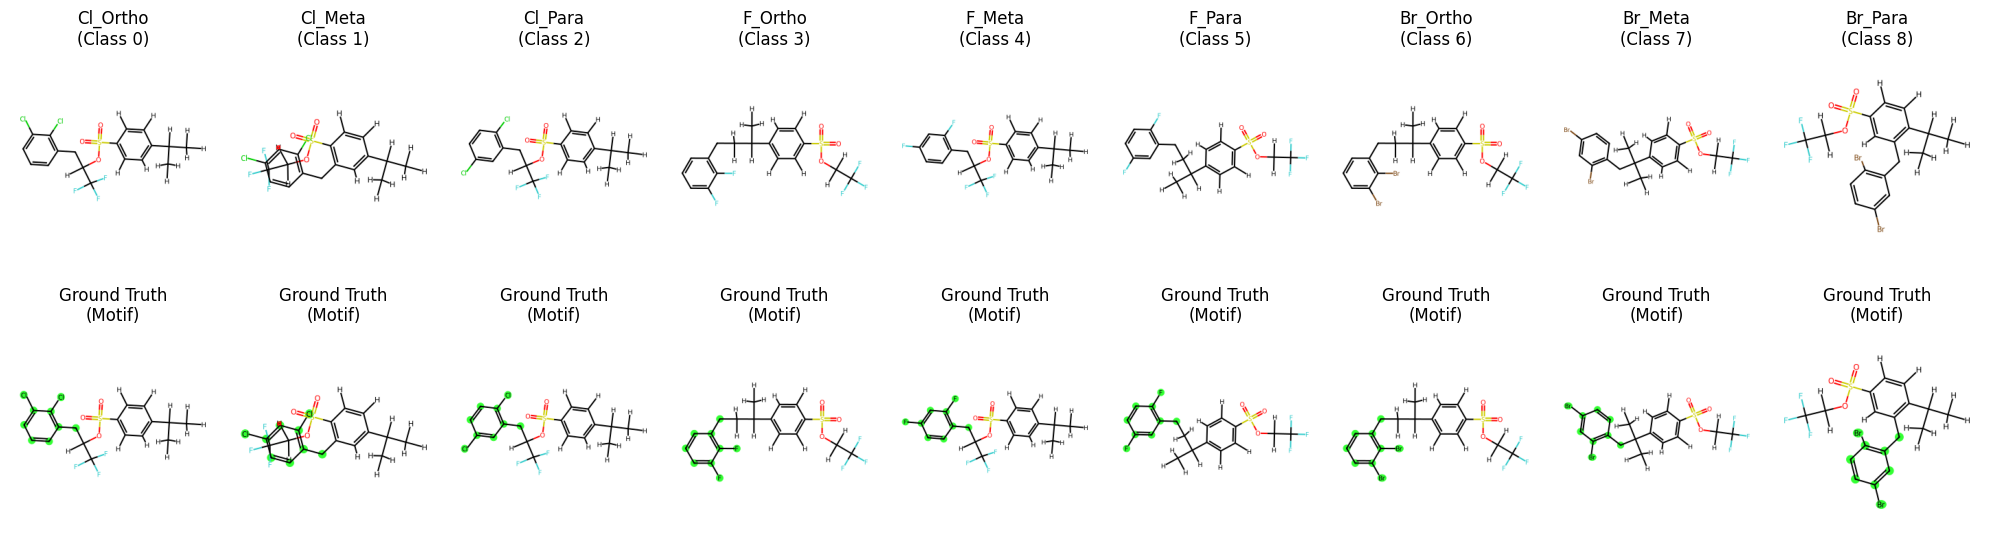

In [10]:
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw
import torch
import numpy as np

# ---------------------------------------------------------
# 1. HELPER: Convert PyG Data back to RDKit Mol
# ---------------------------------------------------------
def pyg_to_rdkit(data):
    """
    Reconstructs an RDKit molecule from a PyG Data object.
    """
    atom_list = ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P', 'H']
    bond_list = [Chem.BondType.SINGLE, Chem.BondType.DOUBLE, 
                 Chem.BondType.TRIPLE, Chem.BondType.AROMATIC]
    
    mol = Chem.RWMol()
    
    # 1. Add Atoms
    # data.x is [num_nodes, num_features]
    node_features = data.x.cpu().detach().numpy()
    for feat in node_features:
        atom_idx = np.argmax(feat)
        atom_symbol = atom_list[atom_idx]
        mol.AddAtom(Chem.Atom(atom_symbol))
        
    # 2. Add Bonds
    # data.edge_index is [2, num_edges]
    # data.edge_attr is [num_edges, num_bond_types]
    edge_index = data.edge_index.cpu().detach().numpy()
    edge_attr = data.edge_attr.cpu().detach().numpy()
    
    # Keep track of added bonds to avoid duplicates (since PyG is undirected)
    added_bonds = set()
    
    for k in range(edge_index.shape[1]):
        i, j = edge_index[0, k], edge_index[1, k]
        
        # Always add bond such that i < j to handle undirected uniqueness
        if i > j: 
            i, j = j, i
            
        if (i, j) in added_bonds:
            continue
            
        bond_type_idx = np.argmax(edge_attr[k])
        bond_type = bond_list[bond_type_idx]
        
        mol.AddBond(int(i), int(j), bond_type)
        added_bonds.add((i, j))
        
    try:
        Chem.SanitizeMol(mol)
    except:
        # Sometimes aromaticity reconstruction is tricky without explicit flags, 
        # but for visualization this usually works fine.
        pass
        
    return mol.GetMol()

# ---------------------------------------------------------
# 2. PLOTTING LOGIC
# ---------------------------------------------------------
def visualize_classes(dataset):
    # Class names for labels
    class_names = [
        'Cl_Ortho', 'Cl_Meta', 'Cl_Para',
        'F_Ortho', 'F_Meta', 'F_Para',
        'Br_Ortho', 'Br_Meta', 'Br_Para'
    ]
    
    # Find one sample for each class
    samples = {}
    for data in dataset:
        label = data.y.item()
        if label not in samples:
            samples[label] = data
        if len(samples) == 9:
            break
            
    # Setup Plot: 2 Rows, 9 Columns
    fig, axes = plt.subplots(2, 9, figsize=(20, 6))
    
    for label in range(9):
        if label not in samples: continue
        
        data = samples[label]
        mol = pyg_to_rdkit(data)
        
        # Identify Motif Atoms from the Mask
        # data.explanation_mask is [num_nodes]
        mask = data.explanation_mask.cpu().numpy()
        motif_atom_indices = [i for i, m in enumerate(mask) if m == 1]
        
        # --- ROW 1: Full Molecule (No Highlight) ---
        img1 = Draw.MolToImage(mol, size=(300, 300))
        axes[0, label].imshow(img1)
        axes[0, label].set_title(f"{class_names[label]}\n(Class {label})")
        axes[0, label].axis('off')
        
        # --- ROW 2: Ground Truth Highlight ---
        # We use highlightAtoms to show the motif
        img2 = Draw.MolToImage(mol, size=(300, 300), 
                               highlightAtoms=motif_atom_indices,
                               highlightColor=(0.2, 1.0, 0.2)) # Green highlight
        
        axes[1, label].imshow(img2)
        axes[1, label].set_title("Ground Truth\n(Motif)")
        axes[1, label].axis('off')

    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 3. RUN IT
# ---------------------------------------------------------
# Assuming 'dataset_final' is available from your previous step
if len(dataset_final) > 0:
    print("Visualizing samples from the generated dataset...")
    visualize_classes(dataset_final)
else:
    print("Dataset is empty! Run the generation script first.")

--- Visualizing Scaffold #1 ---


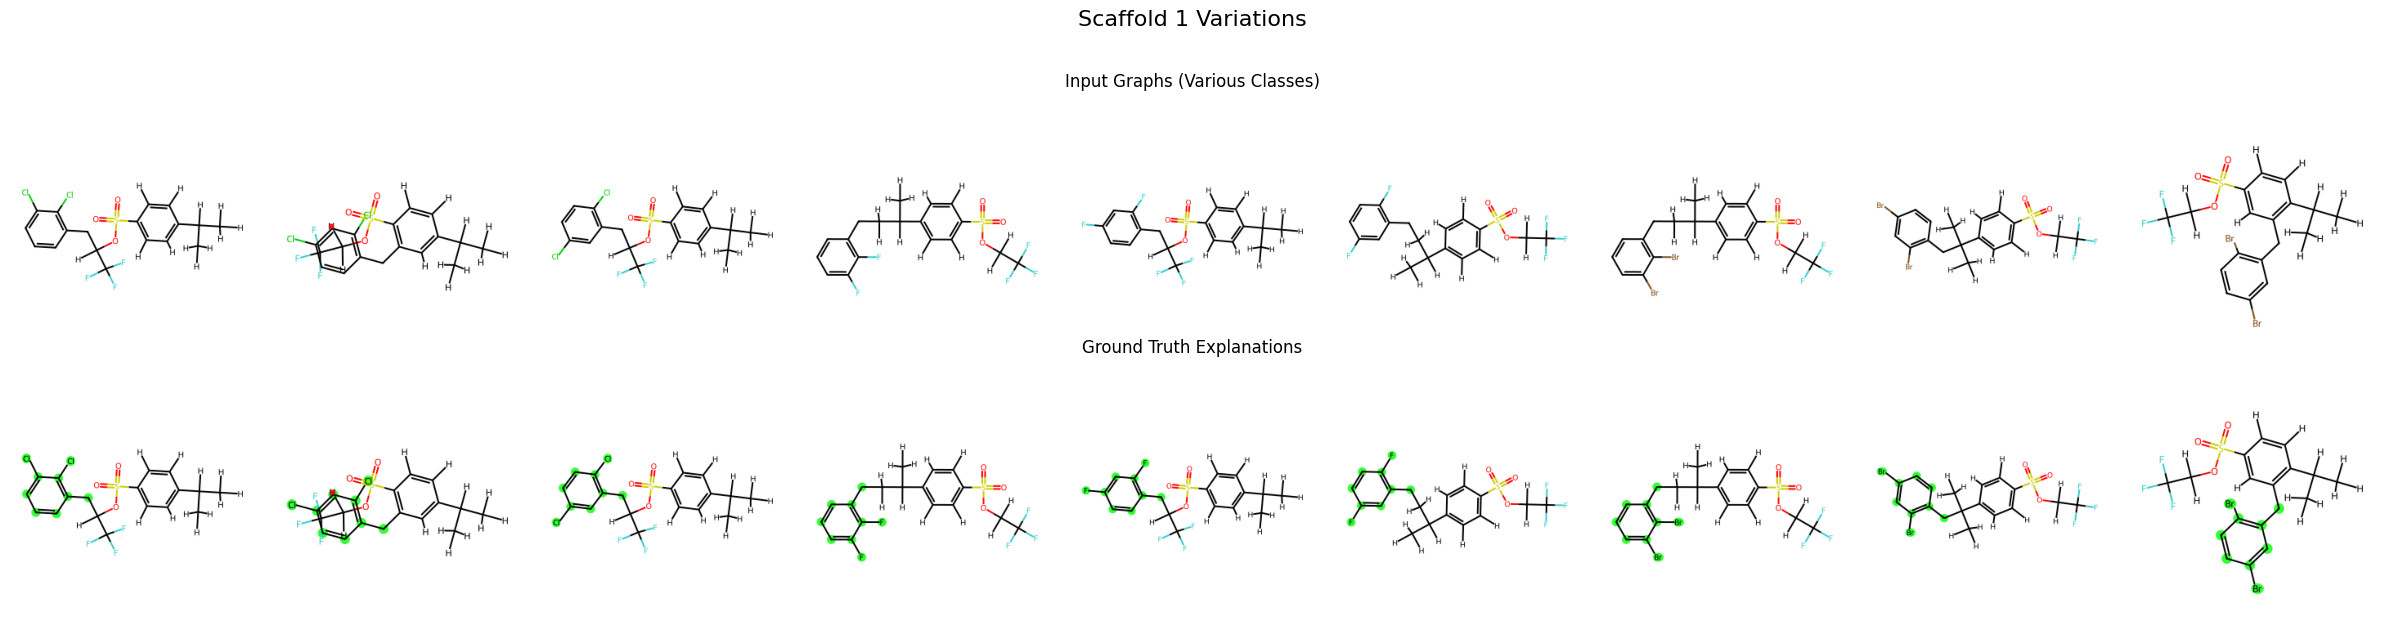



--- Visualizing Scaffold #2 ---


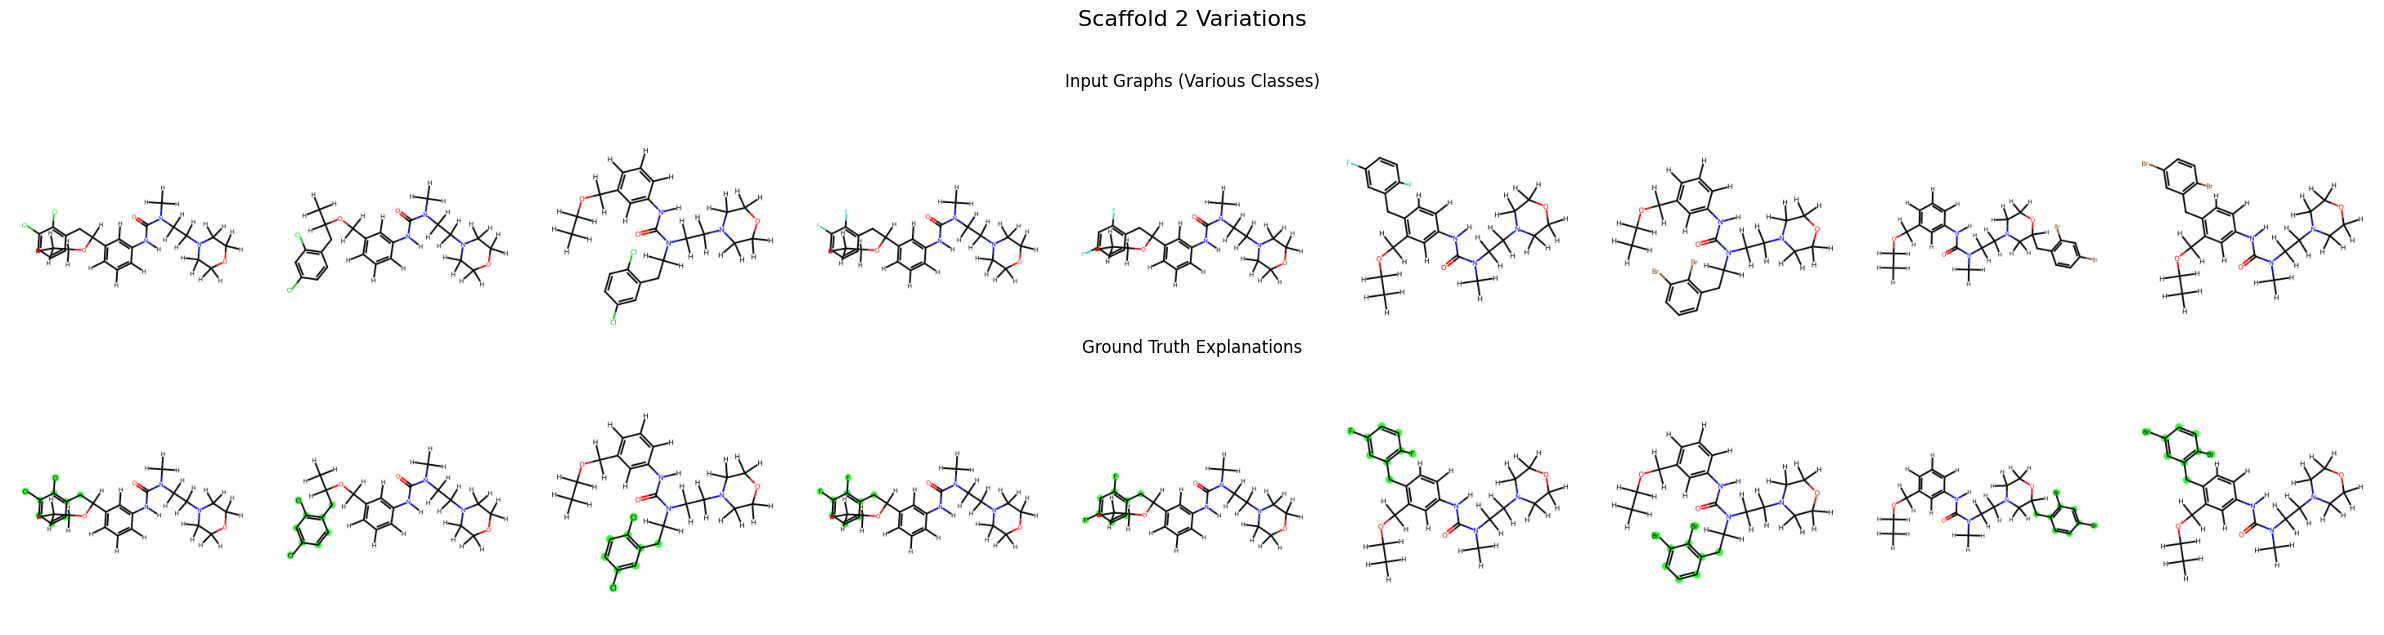



--- Visualizing Scaffold #3 ---


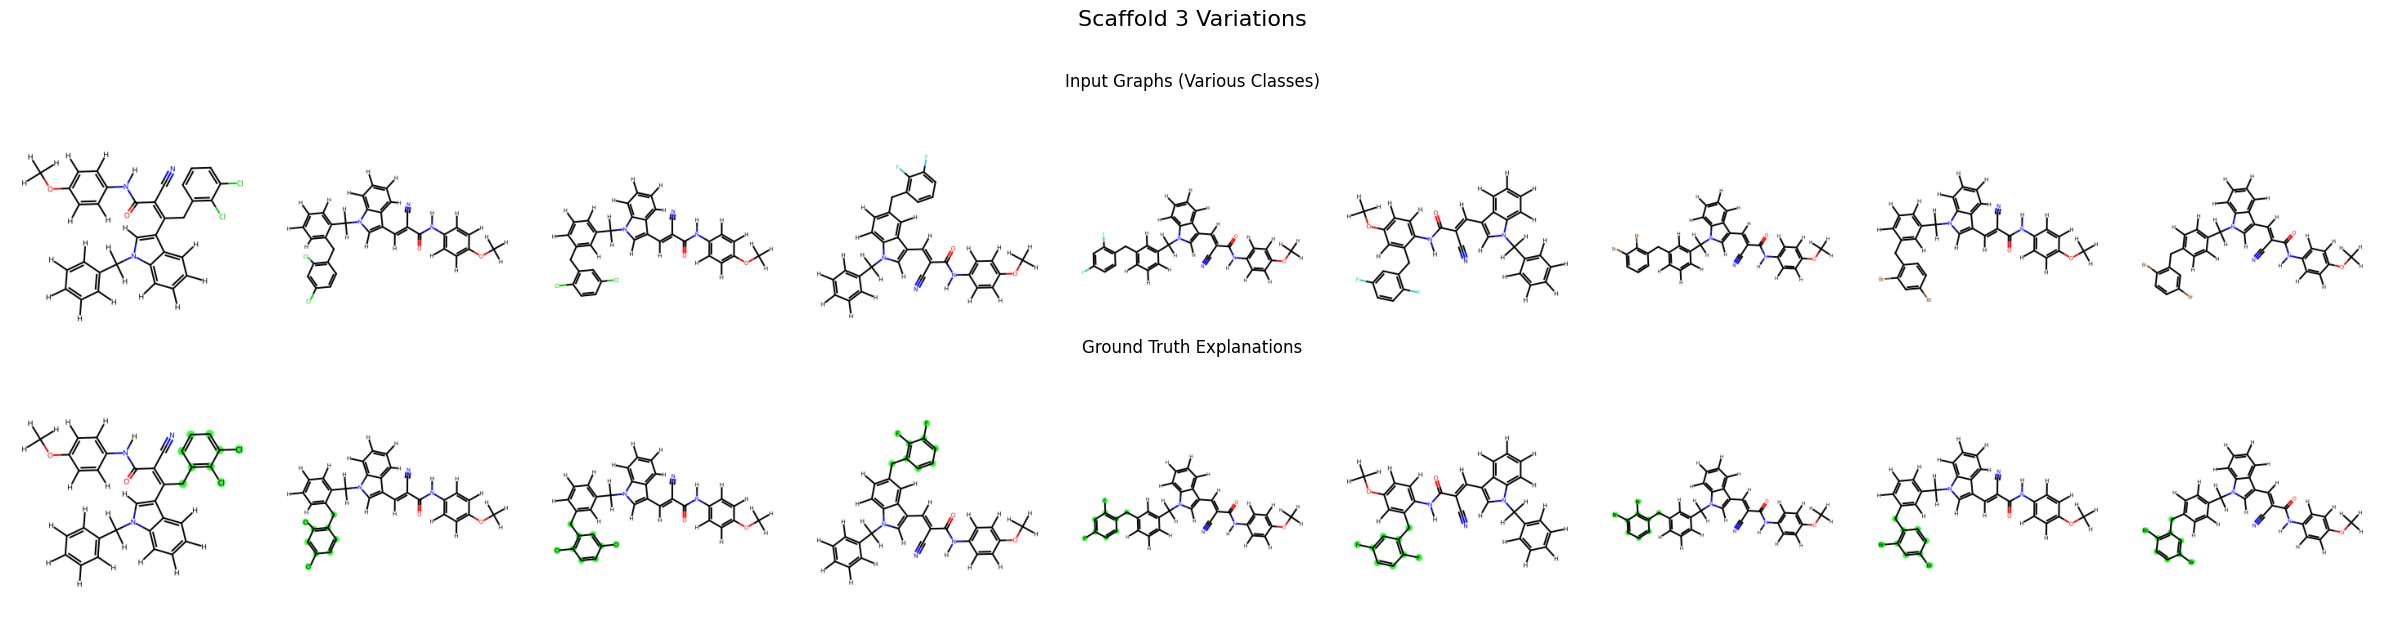



--- Visualizing Scaffold #4 ---


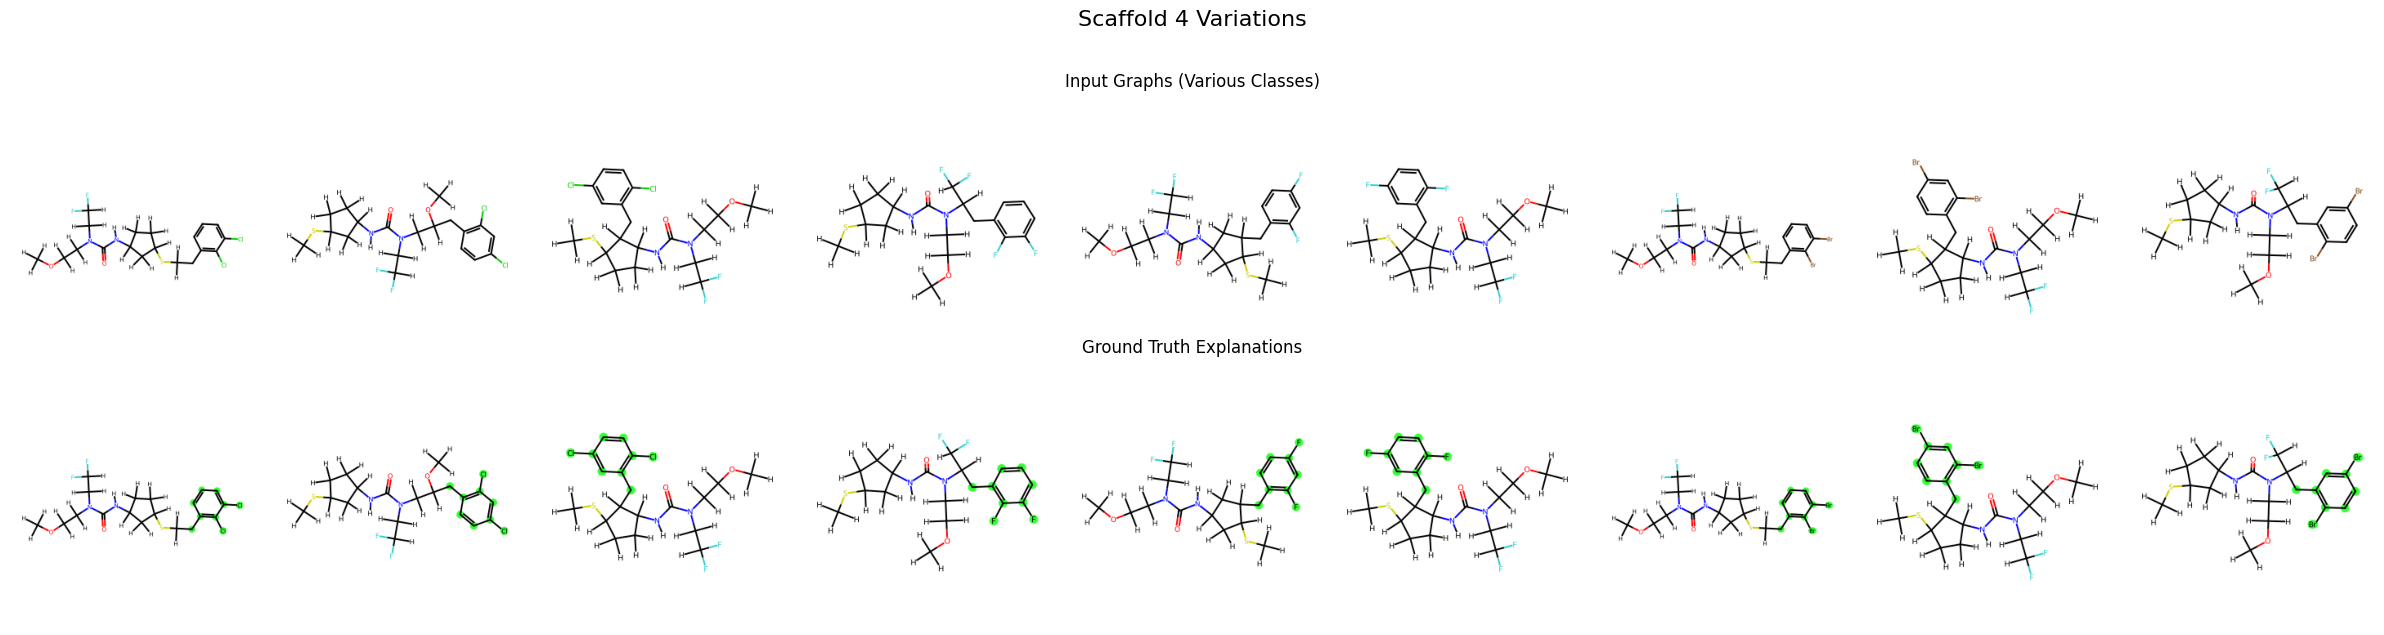



--- Visualizing Scaffold #5 ---


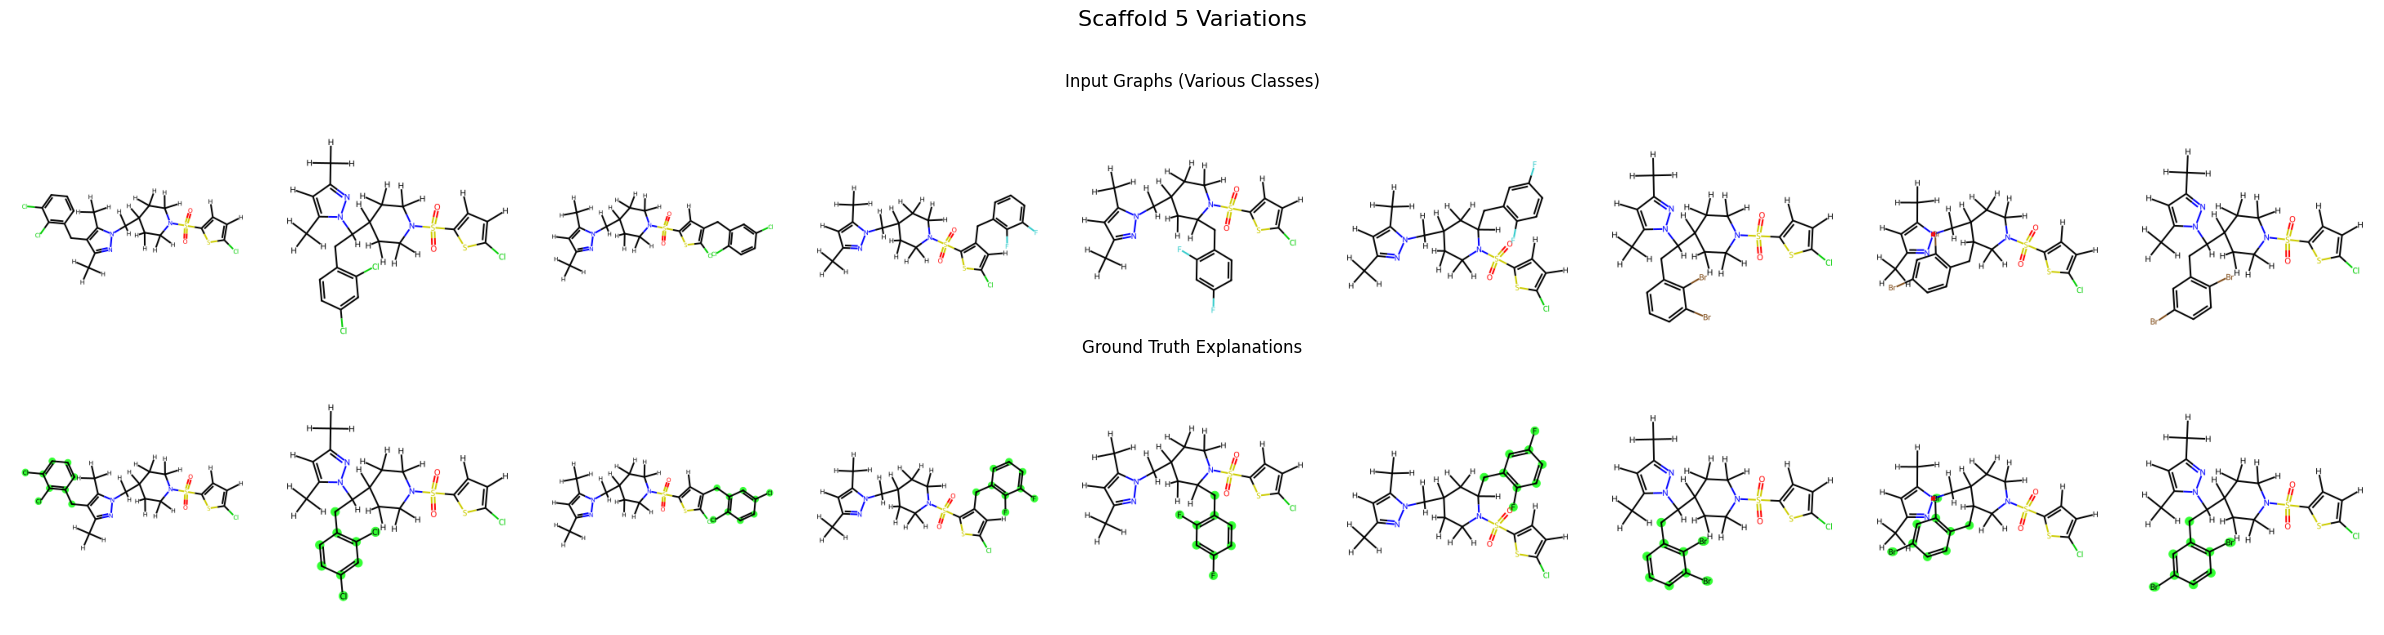



--- Visualizing Scaffold #6 ---


[19:11:41] Explicit valence for atom # 7 N, 4, is greater than permitted
[19:11:41] Explicit valence for atom # 7 N, 4, is greater than permitted
[19:11:41] Explicit valence for atom # 7 N, 4, is greater than permitted
[19:11:41] Explicit valence for atom # 7 N, 4, is greater than permitted
[19:11:41] Explicit valence for atom # 7 N, 4, is greater than permitted
[19:11:41] Explicit valence for atom # 7 N, 4, is greater than permitted
[19:11:41] Explicit valence for atom # 7 N, 4, is greater than permitted
[19:11:41] Explicit valence for atom # 7 N, 4, is greater than permitted
[19:11:41] Explicit valence for atom # 7 N, 4, is greater than permitted


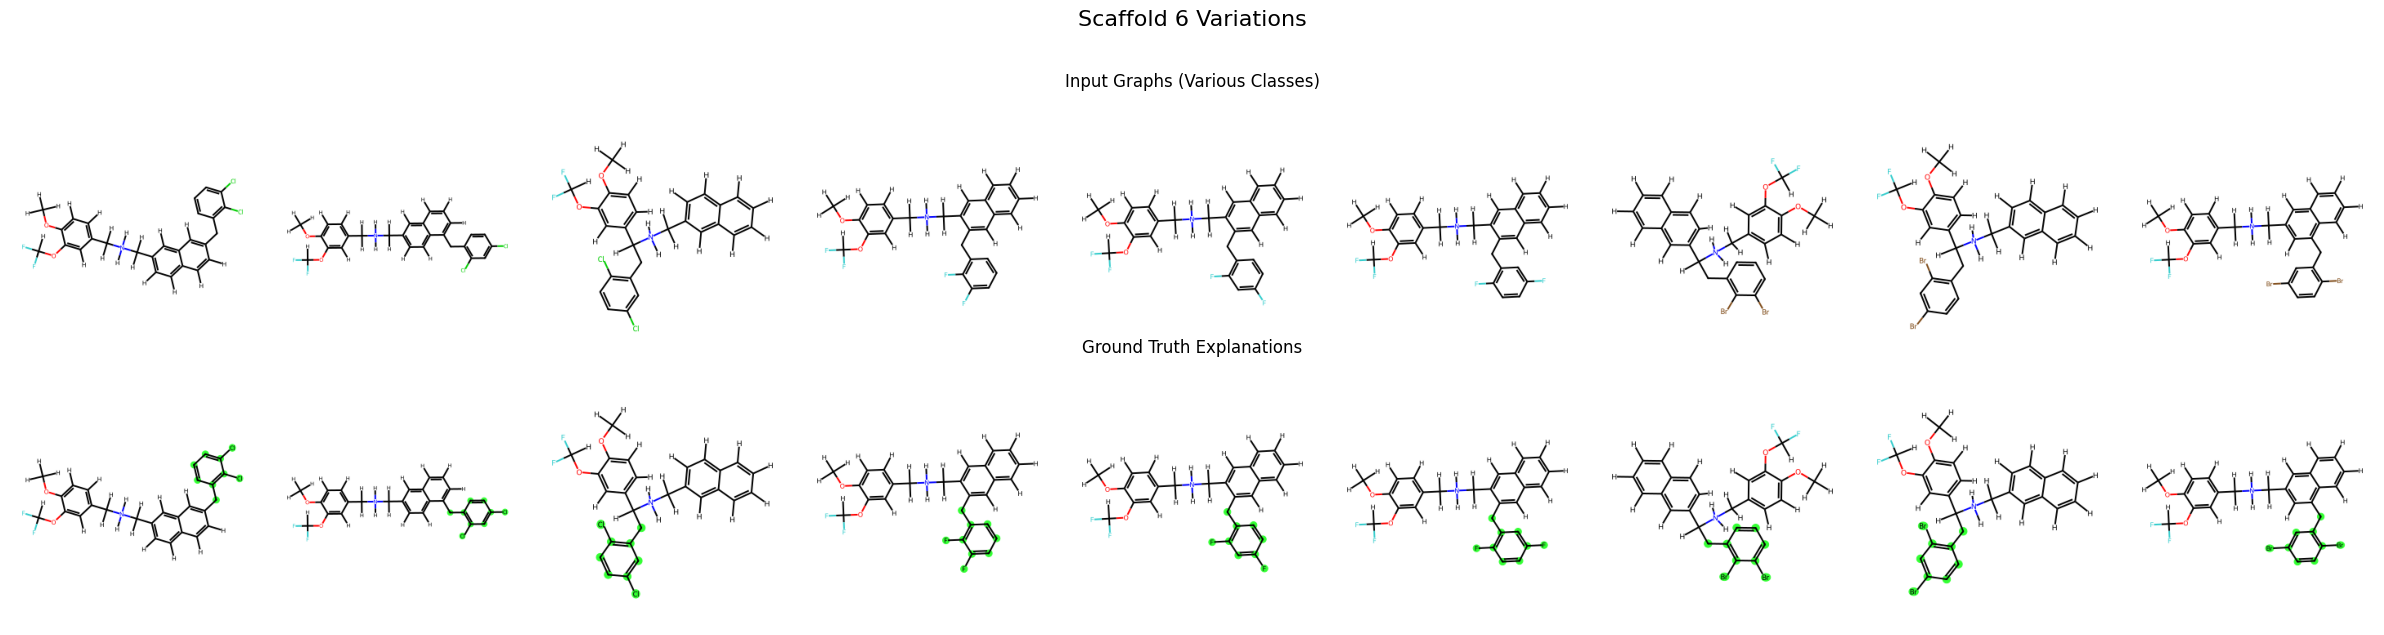

In [11]:
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw
import torch
import numpy as np

# ---------------------------------------------------------
# 1. CONVERTER: PyG Data -> RDKit Mol
# ---------------------------------------------------------
def pyg_to_rdkit(data):
    """Reconstructs RDKit molecule from PyG Data object."""
    atom_list = ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P', 'H']
    bond_list = [Chem.BondType.SINGLE, Chem.BondType.DOUBLE, 
                 Chem.BondType.TRIPLE, Chem.BondType.AROMATIC]
    
    mol = Chem.RWMol()
    
    # Add Atoms
    node_features = data.x.cpu().detach().numpy()
    for feat in node_features:
        atom_idx = np.argmax(feat)
        atom_symbol = atom_list[atom_idx]
        mol.AddAtom(Chem.Atom(atom_symbol))
        
    # Add Bonds
    edge_index = data.edge_index.cpu().detach().numpy()
    edge_attr = data.edge_attr.cpu().detach().numpy()
    added_bonds = set()
    
    for k in range(edge_index.shape[1]):
        i, j = edge_index[0, k], edge_index[1, k]
        if i > j: i, j = j, i # Undirected check
            
        if (i, j) in added_bonds: continue
            
        bond_type_idx = np.argmax(edge_attr[k])
        bond_type = bond_list[bond_type_idx]
        
        mol.AddBond(int(i), int(j), bond_type)
        added_bonds.add((i, j))
        
    try: Chem.SanitizeMol(mol)
    except: pass
    return mol.GetMol()

# ---------------------------------------------------------
# 2. PLOTTING LOGIC FOR 6 SCAFFOLDS
# ---------------------------------------------------------
def visualize_scaffolds(dataset, num_scaffolds=6):
    class_names = [
        'Cl_Ortho', 'Cl_Meta', 'Cl_Para',
        'F_Ortho', 'F_Meta', 'F_Para',
        'Br_Ortho', 'Br_Meta', 'Br_Para'
    ]
    
    # We generated data in blocks of 9. 
    # Index 0-8 = Scaffold 1, Index 9-17 = Scaffold 2, etc.
    
    for scaffold_idx in range(num_scaffolds):
        start_idx = scaffold_idx * 9
        
        # Safety check if we have enough data
        if start_idx + 9 > len(dataset):
            print(f"Dataset only has {len(dataset)} graphs. Stopping at scaffold {scaffold_idx}.")
            break
            
        print(f"--- Visualizing Scaffold #{scaffold_idx + 1} ---")
        
        # Create a new figure for this scaffold (2 rows, 9 columns)
        fig, axes = plt.subplots(2, 9, figsize=(24, 6))
        plt.suptitle(f"Scaffold {scaffold_idx + 1} Variations", fontsize=16, y=1.05)
        
        # Loop through the 9 classes for this specific scaffold
        for class_idx in range(9):
            data = dataset[start_idx + class_idx]
            mol = pyg_to_rdkit(data)
            
            # Ground Truth Mask Indices
            mask = data.explanation_mask.cpu().numpy()
            motif_indices = [i for i, m in enumerate(mask) if m == 1]
            
            # Row 1: The Generated Graph
            img1 = Draw.MolToImage(mol, size=(300, 300))
            axes[0, class_idx].imshow(img1)
            if class_idx == 4: axes[0, class_idx].set_title("Input Graphs (Various Classes)", pad=20, fontsize=12)
            axes[0, class_idx].axis('off')
            
            # Row 2: Ground Truth Highlight
            # We highlight the motif atoms in Green
            img2 = Draw.MolToImage(mol, size=(300, 300), 
                                   highlightAtoms=motif_indices,
                                   highlightColor=(0.2, 1.0, 0.2))
            
            axes[1, class_idx].imshow(img2)
            axes[1, class_idx].set_xlabel(class_names[class_idx], fontsize=10)
            if class_idx == 4: axes[1, class_idx].set_title("Ground Truth Explanations", pad=20, fontsize=12)
            axes[1, class_idx].axis('off')

        plt.tight_layout()
        plt.show()
        print("\n" + "="*80 + "\n")

# ---------------------------------------------------------
# 3. RUN VISUALIZATION
# ---------------------------------------------------------
if len(dataset_final) > 0:
    visualize_scaffolds(dataset_final, num_scaffolds=6)
else:
    print("Dataset is empty! Please run the generation script first.")

In [12]:
import torch
import os
import shutil
from torch_geometric.data import InMemoryDataset

class ZincGraftDataset(InMemoryDataset):
    def __init__(self, root, data_list=None, transform=None, pre_transform=None):
        """
        Args:
            root (str): Root directory where the dataset should be saved.
            data_list (list): The list of Data objects we generated (only needed for first run).
        """
        self._provided_data_list = data_list
        super().__init__(root, transform, pre_transform)
        
        # Load the data we just processed or verified exists
        if os.path.exists(self.processed_paths[0]):
             # --- FIX IS HERE: add weights_only=False ---
            self.data, self.slices = torch.load(self.processed_paths[0], weights_only=False)
        else:
            # If load failed or file didn't exist, we might have just processed it.
            # But normally super().__init__ calls process(), which saves it.
            # Then we load it back.
            pass

    @property
    def processed_file_names(self):
        return ['data.pt']

    def process(self):
        if self._provided_data_list is None:
            raise FileNotFoundError("Processed file not found and no data_list provided to generate it!")
            
        print(f"Saving new dataset to {self.processed_paths[0]}...")
        # Save happens here using the standard PyG collation
        data, slices = self.collate(self._provided_data_list)
        torch.save((data, slices), self.processed_paths[0])

# ------------------------------------------------------------------
# IMPORTANT: Delete old corrupt files before re-running!
# ------------------------------------------------------------------
# The error implies a file might already exist at that path that 
# was saved/loaded incompatibly or is partially corrupt.
# It is safest to clear the directory for a fresh start.

DATASET_ROOT = 'zinc_di_halo_benzene_data' # Or your specific path

if os.path.exists(DATASET_ROOT):
    print(f"Removing old dataset directory at {DATASET_ROOT} to avoid conflicts...")
    shutil.rmtree(DATASET_ROOT)

# Now instantiate
dataset = ZincGraftDataset(root=DATASET_ROOT, data_list=dataset_final)

print("Dataset successfully created and loaded!")

Processing...


Saving new dataset to zinc_di_halo_benzene_data/processed/data.pt...


Done!


Dataset successfully created and loaded!


In [13]:
import torch
import numpy as np
from collections import Counter

def inspect_dataset_statistics(dataset):
    print("==================================================")
    print("           DATASET STATISTICS REPORT              ")
    print("==================================================")
    
    # 1. Basic Counts
    num_graphs = len(dataset)
    print(f"Total Graphs: {num_graphs}")
    
    # 2. Feature Dimensions (Check first graph)
    sample = dataset[0]
    num_node_features = sample.x.shape[1]
    num_edge_features = sample.edge_attr.shape[1]
    
    print(f"\n[Dimensions]")
    print(f"Node Feature Dim (x):        {num_node_features}")
    print(f"Edge Feature Dim (edge_attr):{num_edge_features}")
    
    # 3. Check One-Hot Encoding Validity
    # We check if features sum to 1 (valid one-hot) or 0 (unknown atom/bond)
    node_sums = sample.x.sum(dim=1)
    edge_sums = sample.edge_attr.sum(dim=1)
    
    is_node_one_hot = torch.all((node_sums == 1) | (node_sums == 0)).item()
    is_edge_one_hot = torch.all((edge_sums == 1) | (edge_sums == 0)).item()
    
    print(f"\n[Encoding Check]")
    print(f"Are Nodes One-Hot?           {is_node_one_hot}") 
    print(f"Are Edges One-Hot?           {is_edge_one_hot}")
    
    # 4. Class Balance
    labels = [data.y.item() for data in dataset]
    class_counts = Counter(labels)
    
    print(f"\n[Class Distribution]")
    print(f"{'Class ID':<10} {'Name':<20} {'Count':<10}")
    print("-" * 40)
    
    class_names = [
        'Cl_Ortho_Me', 'Cl_Meta_Me', 'Cl_Para_Me',
        'F_Ortho_Me',  'F_Meta_Me',  'F_Para_Me',
        'Br_Ortho_Me', 'Br_Meta_Me', 'Br_Para_Me'
    ]
    
    # Check for perfect balance
    imbalance = False
    for i in range(9):
        count = class_counts.get(i, 0)
        print(f"{i:<10} {class_names[i]:<20} {count:<10}")
        if count != num_graphs / 9:
            imbalance = True
            
    if not imbalance:
        print("\nSUCCESS: Dataset is perfectly balanced.")
    else:
        print("\nWARNING: Dataset is NOT perfectly balanced.")

    # 5. Graph Sizes
    num_nodes = [data.num_nodes for data in dataset]
    num_edges = [data.num_edges for data in dataset]
    
    print(f"\n[Graph Topology]")
    print(f"Avg Nodes: {np.mean(num_nodes):.2f} +/- {np.std(num_nodes):.2f}")
    print(f"Avg Edges: {np.mean(num_edges):.2f} +/- {np.std(num_edges):.2f}")

    # 6. GINEConv Readiness Check
    print(f"\n[GINEConv Compatibility]")
    if num_node_features == num_edge_features:
        print("PASS: Node and Edge dims match. Direct addition possible.")
    else:
        print(f"NOTICE: Mismatch ({num_node_features} vs {num_edge_features}).")
        print("ACTION: You must use a Linear projection for edge_attr in your GNN.")

# Run the inspection
inspect_dataset_statistics(dataset)

           DATASET STATISTICS REPORT              
Total Graphs: 9000

[Dimensions]
Node Feature Dim (x):        10
Edge Feature Dim (edge_attr):4

[Encoding Check]
Are Nodes One-Hot?           True
Are Edges One-Hot?           True

[Class Distribution]
Class ID   Name                 Count     
----------------------------------------
0          Cl_Ortho_Me          1000      
1          Cl_Meta_Me           1000      
2          Cl_Para_Me           1000      
3          F_Ortho_Me           1000      
4          F_Meta_Me            1000      
5          F_Para_Me            1000      
6          Br_Ortho_Me          1000      
7          Br_Meta_Me           1000      
8          Br_Para_Me           1000      

SUCCESS: Dataset is perfectly balanced.

[Graph Topology]
Avg Nodes: 51.53 +/- 8.50
Avg Edges: 108.60 +/- 18.04

[GINEConv Compatibility]
NOTICE: Mismatch (10 vs 4).
ACTION: You must use a Linear projection for edge_attr in your GNN.

[Class Distribution]
Class ID   Name  

# 7. Train a 4-layer GINE (5-fold CV + held-out test)
This section trains a 4-layer GINEConv model using a classic pipeline: for each seed we create a stratified train+val vs test split, run 5-fold CV on train+val (with an inner train/val split per fold), and evaluate each fold's best checkpoint on the held-out test set.
We report accuracy mean ± std across all folds and all seeds.

In [ ]:
import os
import time
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, global_mean_pool

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_device() -> torch.device:
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')


@torch.no_grad()
def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    pred = logits.argmax(dim=-1)
    return (pred == y).float().mean().item()


class GINE4Layer(nn.Module):
    def __init__(
        self,
        in_dim: int,
        edge_dim: int,
        hidden_dim: int,
        num_classes: int,
        num_layers: int = 4,
        dropout: float = 0.2,
    ):
        super().__init__()
        assert num_layers == 4, "This notebook cell implements the requested 4-layer GINE."
        self.dropout = dropout

        self.node_encoder = nn.Linear(in_dim, hidden_dim)
        self.edge_encoder = nn.Linear(edge_dim, hidden_dim)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(inplace=True),
                nn.Linear(hidden_dim, hidden_dim),
            )
            self.convs.append(GINEConv(nn=mlp))
            self.norms.append(nn.BatchNorm1d(hidden_dim))

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        x = self.node_encoder(x)
        edge_attr = self.edge_encoder(edge_attr)

        for conv, bn in zip(self.convs, self.norms):
            x = conv(x, edge_index, edge_attr)
            x = bn(x)
            x = F.relu(x, inplace=True)
            x = F.dropout(x, p=self.dropout, training=self.training)

        g = global_mean_pool(x, batch)
        return self.classifier(g)

In [ ]:
def make_splits_indices(y: np.ndarray, seed: int, test_size: float, k_folds: int):
    """Returns (trainval_idx, test_idx, folds) where folds is list of (train_idx, val_idx) in index space."""
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    (trainval_idx, test_idx) = next(splitter.split(np.zeros_like(y), y))

    y_trainval = y[trainval_idx]
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=seed)
    folds = []
    for fold_train_rel, fold_val_rel in skf.split(np.zeros_like(y_trainval), y_trainval):
        fold_train_idx = trainval_idx[fold_train_rel]
        fold_val_idx = trainval_idx[fold_val_rel]
        folds.append((fold_train_idx, fold_val_idx))
    return trainval_idx, test_idx, folds


def train_one_run(
    dataset,
    train_idx: np.ndarray,
    val_idx: np.ndarray,
    test_idx: np.ndarray,
    *,
    seed: int,
    hidden_dim: int = 128,
    batch_size: int = 64,
    max_epochs: int = 200,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    dropout: float = 0.2,
    scheduler_factor: float = 0.5,
    scheduler_patience: int = 10,
    min_lr: float = 1e-6,
    early_stop_patience: int = 25,
    min_delta: float = 1e-4,
    num_workers: int = 0,
    verbose: bool = False,
    device=None,
 ):
    set_seed(seed)
    device = device or get_device()

    # Infer dims from dataset
    sample = dataset[0]
    in_dim = int(sample.x.size(-1))
    edge_dim = int(sample.edge_attr.size(-1))
    num_classes = int(dataset.num_classes) if hasattr(dataset, 'num_classes') else int(torch.unique(torch.tensor([d.y.item() for d in dataset])).numel())

    model = GINE4Layer(
        in_dim=in_dim,
        edge_dim=edge_dim,
        hidden_dim=hidden_dim,
        num_classes=num_classes,
        num_layers=4,
        dropout=dropout,
    ).to(device)

    train_loader = DataLoader(dataset.index_select(torch.tensor(train_idx)), batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(dataset.index_select(torch.tensor(val_idx)), batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(dataset.index_select(torch.tensor(test_idx)), batch_size=batch_size, shuffle=False, num_workers=num_workers)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=scheduler_factor, patience=scheduler_patience, min_lr=min_lr
    )

    best_state = None
    best_val_loss = float('inf')
    best_val_acc = 0.0
    epochs_no_improve = 0

    def run_loader(loader, train: bool):
        if train:
            model.train()
        else:
            model.eval()
        total_loss = 0.0
        total_correct = 0
        total_examples = 0
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch)
            y = batch.y.view(-1).to(device)
            loss = F.cross_entropy(logits, y)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * y.size(0)
            total_correct += (logits.argmax(dim=-1) == y).sum().item()
            total_examples += y.size(0)
        avg_loss = total_loss / max(1, total_examples)
        avg_acc = total_correct / max(1, total_examples)
        return avg_loss, avg_acc

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = run_loader(train_loader, train=True)
        val_loss, val_acc = run_loader(val_loader, train=False)
        scheduler.step(val_loss)

        improved = (best_val_loss - val_loss) > min_delta
        if improved:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and (epoch == 1 or epoch % 10 == 0):
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch:03d} | lr={current_lr:.2e} | train {train_loss:.4f}/{train_acc:.3f} | val {val_loss:.4f}/{val_acc:.3f}")

        if epochs_no_improve >= early_stop_patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best val loss {best_val_loss:.4f}, acc {best_val_acc:.3f}).")
            break

    # Load best checkpoint
    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    test_loss, test_acc = run_loader(test_loader, train=False)
    return {
        'best_val_loss': float(best_val_loss),
        'best_val_acc': float(best_val_acc),
        'test_loss': float(test_loss),
        'test_acc': float(test_acc),
        'epochs_ran': int(epoch),
    }

In [ ]:
def run_multiseed_5fold(
    dataset,
    *,
    seeds=(0, 1, 2),
    k_folds: int = 5,
    test_size: float = 0.2,
    hidden_dim: int = 128,
    batch_size: int = 64,
    max_epochs: int = 200,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    dropout: float = 0.2,
    scheduler_factor: float = 0.5,
    scheduler_patience: int = 10,
    min_lr: float = 1e-6,
    early_stop_patience: int = 25,
    min_delta: float = 1e-4,
    num_workers: int = 0,
    verbose: bool = False,
 ):
    device = get_device()
    print(f"Device: {device}")
    print(f"Seeds: {list(seeds)} | k_folds={k_folds} | test_size={test_size}")
    print(f"LR={lr} | sched factor={scheduler_factor} patience={scheduler_patience} min_lr={min_lr}")
    print(f"EarlyStop patience={early_stop_patience} min_delta={min_delta}\n")

    y = np.array([dataset[i].y.item() for i in range(len(dataset))], dtype=np.int64)

    all_results = []
    per_seed_summary = []

    t0 = time.time()
    for seed in seeds:
        trainval_idx, test_idx, folds = make_splits_indices(y=y, seed=int(seed), test_size=test_size, k_folds=k_folds)
        seed_fold_accs = []
        if verbose:
            print(f"\n=== Seed {seed} ===")
            print(f"TrainVal={len(trainval_idx)} | Test={len(test_idx)}")

        for fold_id, (train_idx, val_idx) in enumerate(folds, start=1):
            fold_t0 = time.time()
            out = train_one_run(
                dataset,
                train_idx=train_idx,
                val_idx=val_idx,
                test_idx=test_idx,
                seed=int(seed),
                hidden_dim=hidden_dim,
                batch_size=batch_size,
                max_epochs=max_epochs,
                lr=lr,
                weight_decay=weight_decay,
                dropout=dropout,
                scheduler_factor=scheduler_factor,
                scheduler_patience=scheduler_patience,
                min_lr=min_lr,
                early_stop_patience=early_stop_patience,
                min_delta=min_delta,
                num_workers=num_workers,
                verbose=verbose,
                device=device,
            )
            out.update({'seed': int(seed), 'fold': int(fold_id)})
            all_results.append(out)
            seed_fold_accs.append(out['test_acc'])
            print(f"Seed {seed} | Fold {fold_id}/{k_folds} | test_acc={out['test_acc']:.4f} | best_val_acc={out['best_val_acc']:.4f} | epochs={out['epochs_ran']} | {time.time()-fold_t0:.1f}s")

        seed_mean = float(np.mean(seed_fold_accs))
        seed_std = float(np.std(seed_fold_accs, ddof=1)) if len(seed_fold_accs) > 1 else 0.0
        per_seed_summary.append({'seed': int(seed), 'mean_test_acc': seed_mean, 'std_test_acc': seed_std})
        print(f"Seed {seed} summary: mean_test_acc={seed_mean:.4f} ± {seed_std:.4f}")

    all_test_accs = np.array([r['test_acc'] for r in all_results], dtype=np.float64)
    mean_all = float(np.mean(all_test_accs))
    std_all = float(np.std(all_test_accs, ddof=1)) if len(all_test_accs) > 1 else 0.0
    elapsed = time.time() - t0

    print("\n==================================================")
    print("FINAL (all folds × all seeds) TEST ACCURACY")
    print("==================================================")
    print(f"N={len(all_test_accs)} runs | mean={mean_all:.4f} | std={std_all:.4f} | elapsed={elapsed/60:.1f} min")
    return {
        'all_results': all_results,
        'per_seed_summary': per_seed_summary,
        'mean_test_acc': mean_all,
        'std_test_acc': std_all,
    }

In [ ]:
# ---- GPU / Environment preflight (recommended on cluster) ----
import torch
import torch_geometric
from torch_geometric.data import Batch

print(f"torch={torch.__version__} | torch.cuda={torch.version.cuda}")
print(f"pyg={torch_geometric.__version__}")
print(f"cuda_available={torch.cuda.is_available()} | cuda_devices={torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"gpu0={torch.cuda.get_device_name(0)}")
else:
    print("WARNING: CUDA not available -> training will run on CPU.")

# Quick forward pass sanity check on selected device
device = get_device()
sample = dataset[0]
b = Batch.from_data_list([sample]).to(device)
probe = GINE4Layer(
    in_dim=int(sample.x.size(-1)),
    edge_dim=int(sample.edge_attr.size(-1)),
    hidden_dim=64,
    num_classes=int(dataset.num_classes),
    num_layers=4,
).to(device)
with torch.no_grad():
    out = probe(b)
print(f"sanity_forward: device={device} | out_shape={tuple(out.shape)}")

In [ ]:
# ---- Config (edit as needed) ----
SEEDS = (0, 1, 2)
K_FOLDS = 5
TEST_SIZE = 0.2  # fraction reserved as a held-out test set per seed

HIDDEN_DIM = 128
BATCH_SIZE = 64
MAX_EPOCHS = 200
DROPOUT = 0.2
WEIGHT_DECAY = 1e-4

LR = 1e-3
SCHED_FACTOR = 0.5
SCHED_PATIENCE = 10
MIN_LR = 1e-6

EARLY_STOP_PATIENCE = 25
MIN_DELTA = 1e-4

VERBOSE = True  # set True for per-epoch logs

# ---- Run ----
results = run_multiseed_5fold(
    dataset,
    seeds=SEEDS,
    k_folds=K_FOLDS,
    test_size=TEST_SIZE,
    hidden_dim=HIDDEN_DIM,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    dropout=DROPOUT,
    scheduler_factor=SCHED_FACTOR,
    scheduler_patience=SCHED_PATIENCE,
    min_lr=MIN_LR,
    early_stop_patience=EARLY_STOP_PATIENCE,
    min_delta=MIN_DELTA,
    verbose=VERBOSE,
 )

In [ ]:
# ---- Summary: all folds × all seeds ----
import pandas as pd
import numpy as np

def summarize_cv_results(results_dict: dict):
    """Summarize `results` from run_multiseed_5fold across folds and seeds."""
    runs = results_dict.get('all_results', None)
    if not runs:
        raise ValueError("`results_dict['all_results']` is empty/missing. Run the training cell first.")

    df = pd.DataFrame(runs).copy()
    needed = ['seed', 'fold', 'test_acc', 'test_loss', 'best_val_acc', 'best_val_loss', 'epochs_ran']
    for c in needed:
        if c not in df.columns:
            df[c] = np.nan
    df = df[needed].sort_values(['seed', 'fold']).reset_index(drop=True)

    per_seed = (
        df.groupby('seed', as_index=False)
          .agg(
               n_folds=('fold', 'count'),
               mean_test_acc=('test_acc', 'mean'),
               std_test_acc=('test_acc', lambda x: float(np.std(x, ddof=1)) if len(x) > 1 else 0.0),
               mean_test_loss=('test_loss', 'mean'),
               mean_best_val_acc=('best_val_acc', 'mean'),
               mean_epochs=('epochs_ran', 'mean'),
           )
          .sort_values('seed')
          .reset_index(drop=True)
    )

    overall = pd.DataFrame([{
        'n_runs': int(len(df)),
        'n_seeds': int(df['seed'].nunique()),
        'mean_test_acc': float(df['test_acc'].mean()),
        'std_test_acc': float(np.std(df['test_acc'].to_numpy(), ddof=1)) if len(df) > 1 else 0.0,
        'mean_test_loss': float(df['test_loss'].mean()),
        'mean_best_val_acc': float(df['best_val_acc'].mean()),
        'mean_epochs': float(df['epochs_ran'].mean()),
    }])

    print("================ Per-fold runs (seed, fold) ================")
    display(df)
    print("\n================ Per-seed summary ================")
    display(per_seed)
    print("\n================ Overall (all folds × all seeds) ================")
    display(overall)

    return df, per_seed, overall

df_runs, df_per_seed, df_overall = summarize_cv_results(results)

In [ ]:
# ---- Visualize 1 sample graph per class with true vs predicted labels ----
import numpy as np
import torch
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx
from torch_geometric.data import Batch

# Class names (edit if you want different display names)
CLASS_NAMES = [
    'Cl_Ortho', 'Cl_Meta', 'Cl_Para',
    'F_Ortho', 'F_Meta', 'F_Para',
    'Br_Ortho', 'Br_Meta', 'Br_Para',
],
CLASS_NAMES = list(CLASS_NAMES)  # ensure plain list
if len(CLASS_NAMES) == 1 and isinstance(CLASS_NAMES[0], (list, tuple)):
    CLASS_NAMES = list(CLASS_NAMES[0])

def _infer_atom_list_from_x(x: torch.Tensor):
    # Your earlier code uses either 9 atoms (no H) or 10 atoms (with H).
    if x.size(-1) == 10:
        return ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P', 'H']
    if x.size(-1) == 9:
        return ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P']
    return [f'f{i}' for i in range(int(x.size(-1)))]

@torch.no_grad()
def predict_label(model, data, device):
    model.eval()
    b = Batch.from_data_list([data]).to(device)
    logits = model(b)
    return int(logits.argmax(dim=-1).item())

def _run_loader(model, loader, device, train: bool, optimizer=None):
    if train:
        model.train()
    else:
        model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch)
        yy = batch.y.view(-1).to(device)
        loss = F.cross_entropy(logits, yy)
        if train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
        total_loss += float(loss.item()) * yy.size(0)
        total_correct += int((logits.argmax(dim=-1) == yy).sum().item())
        total_examples += int(yy.size(0))
    return (total_loss / max(1, total_examples)), (total_correct / max(1, total_examples))

def train_single_model_no_test_leak(dataset, seed: int = 0, fold_id: int = 1):
    """
    Trains ONE model for visualization without test leakage:
    - create trainval/test with `make_splits_indices`
    - pick one CV fold inside trainval to form train/val
    - early-stop on val
    - evaluate on test ONCE at the end
    Returns: (model, device, test_idx)
    """
    set_seed(seed)
    device = get_device()

    y = np.array([dataset[i].y.item() for i in range(len(dataset))], dtype=np.int64)
    trainval_idx, test_idx, folds = make_splits_indices(y=y, seed=int(seed), test_size=TEST_SIZE, k_folds=K_FOLDS)
    if not folds:
        raise ValueError("No folds produced; check K_FOLDS and dataset size.")
    fold_id = int(fold_id)
    if fold_id < 1 or fold_id > len(folds):
        raise ValueError(f"fold_id must be in [1, {len(folds)}]")

    train_idx, val_idx = folds[fold_id - 1]

    train_loader = DataLoader(dataset.index_select(torch.tensor(train_idx)), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(dataset.index_select(torch.tensor(val_idx)), batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(dataset.index_select(torch.tensor(test_idx)), batch_size=BATCH_SIZE, shuffle=False)

    sample0 = dataset[0]
    model = GINE4Layer(
        in_dim=int(sample0.x.size(-1)),
        edge_dim=int(sample0.edge_attr.size(-1)),
        hidden_dim=HIDDEN_DIM,
        num_classes=int(dataset.num_classes),
        num_layers=4,
        dropout=DROPOUT,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=SCHED_FACTOR, patience=SCHED_PATIENCE, min_lr=MIN_LR
    )

    best_state = None
    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        _train_loss, _train_acc = _run_loader(model, train_loader, device, train=True, optimizer=optimizer)
        val_loss, val_acc = _run_loader(model, val_loader, device, train=False)
        scheduler.step(val_loss)

        improved = (best_val_loss - val_loss) > MIN_DELTA
        if improved:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if VERBOSE and (epoch == 1 or epoch % 10 == 0):
            print(f"[viz-train] Epoch {epoch:03d} | val_loss={val_loss:.4f} | val_acc={val_acc:.3f}")

        if epochs_no_improve >= EARLY_STOP_PATIENCE:
            if VERBOSE:
                print(f"[viz-train] Early stop at epoch {epoch} (best val loss {best_val_loss:.4f}).")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    # Evaluate test ONCE (no leakage)
    test_loss, test_acc = _run_loader(model, test_loader, device, train=False)
    print(f"[viz-eval] Test (single pass): loss={test_loss:.6f} acc={test_acc:.4f}")
    return model, device, np.array(test_idx, dtype=np.int64)

def _plot_graph(ax, data, title: str):
    G = to_networkx(data, to_undirected=True)
    pos = nx.spring_layout(G, seed=0)
    atom_list = _infer_atom_list_from_x(data.x)
    labels = {}
    for i in range(data.num_nodes):
        if data.x.dim() == 2 and int(data.x.size(-1)) == len(atom_list):
            labels[i] = atom_list[int(data.x[i].argmax().item())]
        else:
            labels[i] = str(i)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=240, node_color='lightgray', edgecolors='k', linewidths=0.6)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.5, width=1.0)
    nx.draw_networkx_labels(G, pos, ax=ax, labels=labels, font_size=8)
    ax.set_title(title)
    ax.set_axis_off()

# Choose which seed/fold for visualization (uses the same split logic; no retraining of full CV required)
VIZ_SEED = 0
VIZ_FOLD = 1
print(f"Visualizing predictions using seed={VIZ_SEED}, fold={VIZ_FOLD} (early-stop on val; test evaluated once).")

viz_model, viz_device, viz_test_idx = train_single_model_no_test_leak(dataset, seed=VIZ_SEED, fold_id=VIZ_FOLD)

# Pick one test example per class (0..8)
by_class = {c: None for c in range(len(CLASS_NAMES))}
for i in viz_test_idx.tolist():
    y = int(dataset[i].y.item())
    if by_class.get(y) is None:
        by_class[y] = i
    if all(v is not None for v in by_class.values()):
        break

missing = [c for c, v in by_class.items() if v is None]
if missing:
    print(f"WARNING: could not find test examples for classes: {missing}")

fig, axes = plt.subplots(3, 3, figsize=(14, 12), constrained_layout=True)
for c in range(len(CLASS_NAMES)):
    ax = axes[c // 3, c % 3]
    idx = by_class[c]
    if idx is None:
        ax.set_axis_off()
        ax.set_title(f"{CLASS_NAMES[c]} (id={c}) MISSING")
        continue
    d = dataset[idx]
    true_c = int(d.y.item())
    pred_c = predict_label(viz_model, d, viz_device)
    title = f"{CLASS_NAMES[c]} (id={c}) true={true_c} pred={pred_c} ({CLASS_NAMES[pred_c]})"
    _plot_graph(ax, d, title)
plt.show()

## BCos GINE

In [ ]:
import sys
from pathlib import Path

current_dir = Path.cwd()

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'bcosgnn').is_dir():
            return p
    raise RuntimeError('Could not locate repo root (pyproject.toml + bcosgnn/).')

project_root = find_repo_root(current_dir)

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Repo root added: {project_root}")

Repo root added: /home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique


In [15]:
import random
from collections import defaultdict
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics import roc_auc_score
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx
from torch_geometric.nn.conv import GINEConv
from torch_geometric.nn.aggr import MeanAggregation

from tqdm.auto import tqdm

from bcos.modules import BcosLinear
from bcosgnn.explain_edge_attr import explain as explain_edge_attr
import os
import shutil
from torch_geometric.data import InMemoryDataset

/home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/codes/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### BCos Model Definition

In [16]:

# 4-layer BCos-GINE for `zinc_dichloro` (continuous x and edge_attr)
class BCosGINE(nn.Module):
    def __init__(
        self,
        node_dim: int,
        edge_dim: int,
        *,
        hidden_dim: int = 128,
        num_layers: int = 4,
        num_classes: int = 9,
        b: float = 2.0,
        max_out: int = 1,
        dropout: float = 0.5,
    ):
        super().__init__()
        self.lin_node = BcosLinear(node_dim, hidden_dim, b=b, max_out=max_out)
        self.lin_edge = BcosLinear(edge_dim, hidden_dim, b=b, max_out=max_out)
        self.convs = nn.ModuleList([
            GINEConv(BcosLinear(hidden_dim, hidden_dim, b=b, max_out=max_out), train_eps=False)
            for _ in range(num_layers)
        ])
        self.norms = nn.ModuleList([nn.BatchNorm1d(hidden_dim) for _ in range(num_layers)])
        self.agg = MeanAggregation()
        self.dropout = nn.Dropout(dropout)
        self.head = BcosLinear(hidden_dim, num_classes, b=b, max_out=max_out)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor, batch: torch.Tensor) -> torch.Tensor:
        x = self.lin_node(x)
        edge_attr = self.lin_edge(edge_attr)
        for conv, bn in zip(self.convs, self.norms):
            x = conv(x, edge_index, edge_attr)
            x = bn(x)
            x = F.relu(x)
        g = self.agg(x, batch)
        g = self.dropout(g)
        return self.head(g)  # [num_graphs, num_classes]

In [17]:
import time
import random
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_device() -> torch.device:
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def _infer_num_classes(ds) -> int:
    ys = torch.tensor([ds[i].y.item() for i in range(len(ds))], dtype=torch.long)
    return int(torch.unique(ys).numel())


def make_splits_indices(y: np.ndarray, seed: int, test_size: float, k_folds: int):
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    (trainval_idx, test_idx) = next(splitter.split(np.zeros_like(y), y))
    y_trainval = y[trainval_idx]
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=seed)
    folds = []
    for fold_train_rel, fold_val_rel in skf.split(np.zeros_like(y_trainval), y_trainval):
        fold_train_idx = trainval_idx[fold_train_rel]
        fold_val_idx = trainval_idx[fold_val_rel]
        folds.append((fold_train_idx, fold_val_idx))
    return trainval_idx, test_idx, folds


def train_one_run_bcos(
    dataset,
    train_idx: np.ndarray,
    val_idx: np.ndarray,
    test_idx: np.ndarray,
    *,
    seed: int,
    hidden_dim: int = 128,
    batch_size: int = 64,
    max_epochs: int = 200,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    scheduler_factor: float = 0.5,
    scheduler_patience: int = 10,
    min_lr: float = 1e-6,
    early_stop_patience: int = 25,
    min_delta: float = 1e-4,
    num_workers: int = 0,
    verbose: bool = False,
    device=None,
    b: float = 2.0,
    max_out: int = 1,
    dropout: float = 0.5,
 ):
    set_seed(seed)
    device = device or get_device()

    sample = dataset[0]
    node_dim = int(sample.x.size(-1))
    edge_dim = int(sample.edge_attr.size(-1))
    num_classes = _infer_num_classes(dataset)

    model = BCosGINE(
        node_dim=node_dim,
        edge_dim=edge_dim,
        hidden_dim=hidden_dim,
        num_layers=4,
        num_classes=num_classes,
        b=b,
        max_out=max_out,
        dropout=dropout,
    ).to(device)

    train_loader = DataLoader(dataset.index_select(torch.tensor(train_idx)), batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(dataset.index_select(torch.tensor(val_idx)), batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(dataset.index_select(torch.tensor(test_idx)), batch_size=batch_size, shuffle=False, num_workers=num_workers)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=scheduler_factor, patience=scheduler_patience, min_lr=min_lr
    )

    best_state = None
    best_val_loss = float('inf')
    best_val_acc = 0.0
    epochs_no_improve = 0

    def run_loader(loader, train: bool):
        if train:
            model.train()
        else:
            model.eval()
        total_loss = 0.0
        total_correct = 0
        total_examples = 0
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            y = batch.y.view(-1).to(device)
            loss = F.cross_entropy(logits, y)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * y.size(0)
            total_correct += (logits.argmax(dim=-1) == y).sum().item()
            total_examples += y.size(0)
        avg_loss = total_loss / max(1, total_examples)
        avg_acc = total_correct / max(1, total_examples)
        return avg_loss, avg_acc

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = run_loader(train_loader, train=True)
        val_loss, val_acc = run_loader(val_loader, train=False)
        scheduler.step(val_loss)

        improved = (best_val_loss - val_loss) > min_delta
        if improved:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and (epoch == 1 or epoch % 10 == 0):
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch:03d} | lr={current_lr:.2e} | train {train_loss:.4f}/{train_acc:.3f} | val {val_loss:.4f}/{val_acc:.3f}")

        if epochs_no_improve >= early_stop_patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best val loss {best_val_loss:.4f}, acc {best_val_acc:.3f}).")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    test_loss, test_acc = run_loader(test_loader, train=False)
    return {
        'best_val_loss': float(best_val_loss),
        'best_val_acc': float(best_val_acc),
        'test_loss': float(test_loss),
        'test_acc': float(test_acc),
        'epochs_ran': int(epoch),
    }


def run_multiseed_5fold_bcos(
    dataset,
    *,
    seeds=(0, 1, 2),
    k_folds: int = 5,
    test_size: float = 0.2,
    hidden_dim: int = 128,
    batch_size: int = 64,
    max_epochs: int = 200,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    scheduler_factor: float = 0.5,
    scheduler_patience: int = 10,
    min_lr: float = 1e-6,
    early_stop_patience: int = 25,
    min_delta: float = 1e-4,
    num_workers: int = 0,
    verbose: bool = False,
    b: float = 2.0,
    max_out: int = 1,
    dropout: float = 0.5,
 ):
    device = get_device()
    print(f"Device: {device}")
    print(f"Seeds: {list(seeds)} | k_folds={k_folds} | test_size={test_size}")
    print(f"LR={lr} | sched factor={scheduler_factor} patience={scheduler_patience} min_lr={min_lr}")
    print(f"EarlyStop patience={early_stop_patience} min_delta={min_delta}\n")

    y = np.array([dataset[i].y.item() for i in range(len(dataset))], dtype=np.int64)

    all_results = []
    per_seed_summary = []

    t0 = time.time()
    for seed in seeds:
        _trainval_idx, test_idx, folds = make_splits_indices(y=y, seed=int(seed), test_size=test_size, k_folds=k_folds)
        seed_fold_accs = []

        for fold_id, (train_idx, val_idx) in enumerate(folds, start=1):
            fold_t0 = time.time()
            out = train_one_run_bcos(
                dataset,
                train_idx=train_idx,
                val_idx=val_idx,
                test_idx=test_idx,
                seed=int(seed),
                hidden_dim=hidden_dim,
                batch_size=batch_size,
                max_epochs=max_epochs,
                lr=lr,
                weight_decay=weight_decay,
                scheduler_factor=scheduler_factor,
                scheduler_patience=scheduler_patience,
                min_lr=min_lr,
                early_stop_patience=early_stop_patience,
                min_delta=min_delta,
                num_workers=num_workers,
                verbose=verbose,
                device=device,
                b=b,
                max_out=max_out,
                dropout=dropout,
            )
            out.update({'seed': int(seed), 'fold': int(fold_id)})
            all_results.append(out)
            seed_fold_accs.append(out['test_acc'])
            print(f"Seed {seed} | Fold {fold_id}/{k_folds} | test_acc={out['test_acc']:.4f} | best_val_acc={out['best_val_acc']:.4f} | epochs={out['epochs_ran']} | {time.time()-fold_t0:.1f}s")

        seed_mean = float(np.mean(seed_fold_accs))
        seed_std = float(np.std(seed_fold_accs, ddof=1)) if len(seed_fold_accs) > 1 else 0.0
        per_seed_summary.append({'seed': int(seed), 'mean_test_acc': seed_mean, 'std_test_acc': seed_std})
        print(f"Seed {seed} summary: mean_test_acc={seed_mean:.4f} ± {seed_std:.4f}")

    all_test_accs = np.array([r['test_acc'] for r in all_results], dtype=np.float64)
    mean_all = float(np.mean(all_test_accs))
    std_all = float(np.std(all_test_accs, ddof=1)) if len(all_test_accs) > 1 else 0.0
    elapsed = time.time() - t0

    print("\n==================================================")
    print("FINAL (all folds × all seeds) TEST ACCURACY (BCos-GINE)")
    print("==================================================")
    print(f"N={len(all_test_accs)} runs | mean={mean_all:.4f} | std={std_all:.4f} | elapsed={elapsed/60:.1f} min")
    return {
        'all_results': all_results,
        'per_seed_summary': per_seed_summary,
        'mean_test_acc': mean_all,
        'std_test_acc': std_all,
    }


BCOS_RESULTS = run_multiseed_5fold_bcos(
    dataset,
    seeds=(0, 1, 2),
    k_folds=5,
    test_size=0.2,
    hidden_dim=128,
    batch_size=64,
    max_epochs=200,
    lr=1e-3,
    weight_decay=1e-4,
    scheduler_factor=0.5,
    scheduler_patience=10,
    min_lr=1e-6,
    early_stop_patience=25,
    min_delta=1e-4,
    num_workers=0,
    verbose=False,
    b=2.0,
    max_out=1,
    dropout=0.5,
)

Device: cuda
Seeds: [0, 1, 2] | k_folds=5 | test_size=0.2
LR=0.001 | sched factor=0.5 patience=10 min_lr=1e-06
EarlyStop patience=25 min_delta=0.0001

Seed 0 | Fold 1/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=67 | 58.4s
Seed 0 | Fold 1/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=67 | 58.4s
Seed 0 | Fold 2/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=77 | 64.3s
Seed 0 | Fold 2/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=77 | 64.3s
Seed 0 | Fold 3/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=74 | 63.4s
Seed 0 | Fold 3/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=74 | 63.4s
Seed 0 | Fold 4/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=72 | 59.3s
Seed 0 | Fold 4/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=72 | 59.3s
Seed 0 | Fold 5/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=84 | 70.6s
Seed 0 summary: mean_test_acc=1.0000 ± 0.0000
Seed 0 | Fold 5/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=84 | 70.6s
Seed 0 summary: mean_te

### Training Report BCos

In [ ]:
# ---- Summary: all folds × all seeds ----
import pandas as pd
import numpy as np

def summarize_cv_results(results_dict: dict):
    """Summarize `results` from run_multiseed_5fold across folds and seeds."""
    runs = results_dict.get('all_results', None)
    if not runs:
        raise ValueError("`results_dict['all_results']` is empty/missing. Run the training cell first.")

    df = pd.DataFrame(runs).copy()
    needed = ['seed', 'fold', 'test_acc', 'test_loss', 'best_val_acc', 'best_val_loss', 'epochs_ran']
    for c in needed:
        if c not in df.columns:
            df[c] = np.nan
    df = df[needed].sort_values(['seed', 'fold']).reset_index(drop=True)

    per_seed = (
        df.groupby('seed', as_index=False)
          .agg(
               n_folds=('fold', 'count'),
               mean_test_acc=('test_acc', 'mean'),
               std_test_acc=('test_acc', lambda x: float(np.std(x, ddof=1)) if len(x) > 1 else 0.0),
               mean_test_loss=('test_loss', 'mean'),
               mean_best_val_acc=('best_val_acc', 'mean'),
               mean_epochs=('epochs_ran', 'mean'),
           )
          .sort_values('seed')
          .reset_index(drop=True)
    )

    overall = pd.DataFrame([{
        'n_runs': int(len(df)),
        'n_seeds': int(df['seed'].nunique()),
        'mean_test_acc': float(df['test_acc'].mean()),
        'std_test_acc': float(np.std(df['test_acc'].to_numpy(), ddof=1)) if len(df) > 1 else 0.0,
        'mean_test_loss': float(df['test_loss'].mean()),
        'mean_best_val_acc': float(df['best_val_acc'].mean()),
        'mean_epochs': float(df['epochs_ran'].mean()),
    }])

    print("================ Per-fold runs (seed, fold) ================")
    display(df)
    print("\n================ Per-seed summary ================")
    display(per_seed)
    print("\n================ Overall (all folds × all seeds) ================")
    display(overall)

    return df, per_seed, overall

df_runs, df_per_seed, df_overall = summarize_cv_results(BCOS_RESULTS)

================ Per-fold runs (seed, fold) ================


,seed,fold,test_acc,test_loss,best_val_acc,best_val_loss,epochs_ran
0,0,1,1.0,0.000097,1.0,0.000098,67
1,0,2,1.0,0.000046,1.0,0.000041,77
2,0,3,1.0,0.000028,1.0,0.000030,74
3,0,4,1.0,0.000066,1.0,0.000061,72
4,0,5,1.0,0.000026,1.0,0.000024,84
5,1,1,1.0,0.000091,1.0,0.000083,68
6,1,2,1.0,0.000099,1.0,0.000088,68
7,1,3,1.0,0.000081,1.0,0.000080,70
8,1,4,1.0,0.000086,1.0,0.000090,67
9,1,5,1.0,0.000104,1.0,0.000098,67



================ Per-seed summary ================


,seed,n_folds,mean_test_acc,std_test_acc,mean_test_loss,mean_best_val_acc,mean_epochs
0,0,5,1.0,0.0,0.000052,1.0,74.8
1,1,5,1.0,0.0,0.000092,1.0,68.0
2,2,5,1.0,0.0,0.000060,1.0,75.2



================ Overall (all folds × all seeds) ================


,n_runs,n_seeds,mean_test_acc,std_test_acc,mean_test_loss,mean_best_val_acc,mean_epochs
0,15,3,1.0,0.0,0.000068,1.0,72.666667


### Bcos Explainations

In [ ]:
import random
import numpy as np
import torch
import torch.nn.functional as F

from torch_geometric.loader import DataLoader
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score

from bcosgnn.explain_edge_attr import explain as explain_edge_attr


# -------------------------
# Option B: Train final model + run explanations on test
# -------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 0
TEST_SIZE = 0.2

HIDDEN_DIM = 128
BATCH_SIZE = 64
LR = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 200
EARLY_STOP_PATIENCE = 25
MIN_DELTA = 1e-4

SCHED_FACTOR = 0.5
SCHED_PATIENCE = 10
MIN_LR = 1e-6

# BCos params (match your training cell)
BCOS_B = 2.0
BCOS_MAX_OUT = 1
DROPOUT = 0.5

# Explanation settings
TOPK_MODE = "gt"  # "gt" = k = (#gt nodes), or set integer like 10


def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_labels(ds):
    ys = []
    for d in ds:
        y = d.y
        if torch.is_tensor(y):
            y = int(y.view(-1)[0].item())
        ys.append(y)
    return np.array(ys, dtype=np.int64)


def stratified_trainval_test_split(ds, test_size=0.2, seed=0):
    y = get_labels(ds)
    idx = np.arange(len(ds))

    sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    trainval_idx, test_idx = next(sss.split(idx, y))

    return trainval_idx, test_idx


def train_final_model_with_holdout(trainval_ds, num_classes: int, seed: int):
    # small val split for early stopping (10% of trainval)
    y = get_labels(trainval_ds)
    idx = np.arange(len(trainval_ds))
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=seed)
    tr_idx, va_idx = next(sss.split(idx, y))

    train_ds = [trainval_ds[i] for i in tr_idx]
    val_ds = [trainval_ds[i] for i in va_idx]

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    node_dim = int(trainval_ds[0].x.shape[-1])
    edge_dim = int(trainval_ds[0].edge_attr.shape[-1]) if getattr(trainval_ds[0], "edge_attr", None) is not None else 0

    model = BCosGINE(
        node_dim=node_dim,
        edge_dim=edge_dim,
        hidden_dim=HIDDEN_DIM,
        num_classes=num_classes,
        b=BCOS_B,
        max_out=BCOS_MAX_OUT,
        dropout=DROPOUT,
    ).to(DEVICE)

    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=SCHED_FACTOR, patience=SCHED_PATIENCE, min_lr=MIN_LR
    )

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    bad = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        train_losses = []
        for batch in train_loader:
            batch = batch.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = F.cross_entropy(logits, batch.y.view(-1))
            loss.backward()
            opt.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        val_true, val_pred = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(DEVICE)
                logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                loss = F.cross_entropy(logits, batch.y.view(-1))
                val_losses.append(loss.item())
                val_true.extend(batch.y.view(-1).detach().cpu().numpy().tolist())
                val_pred.extend(logits.argmax(dim=-1).detach().cpu().numpy().tolist())

        val_loss = float(np.mean(val_losses)) if val_losses else float("inf")
        val_acc = accuracy_score(val_true, val_pred) if len(val_true) else float("nan")

        sched.step(val_loss)

        improved = (best_val_loss - val_loss) > MIN_DELTA
        if improved:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            bad = 0
        else:
            bad += 1

        if epoch % 10 == 0 or epoch == 1:
            lr_now = opt.param_groups[0]["lr"]
            print(f"Epoch {epoch:03d} | train_loss={np.mean(train_losses):.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | lr={lr_now:.2e}")

        if bad >= EARLY_STOP_PATIENCE:
            print(f"Early stop at epoch {epoch} (best epoch {best_epoch}, best val_loss {best_val_loss:.4f})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, {"best_epoch": best_epoch, "best_val_loss": best_val_loss}


def eval_accuracy(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            y_true.extend(batch.y.view(-1).detach().cpu().numpy().tolist())
            y_pred.extend(logits.argmax(dim=-1).detach().cpu().numpy().tolist())
    return accuracy_score(y_true, y_pred)


def node_scores_from_contrib(x_contrib: torch.Tensor) -> np.ndarray:
    # x_contrib: [num_nodes, num_features] -> scalar per node
    scores = x_contrib.abs().sum(dim=-1)
    return scores.detach().cpu().numpy()


def jaccard_at_k(scores: np.ndarray, gt_mask: np.ndarray, k: int) -> float:
    if k <= 0:
        return float("nan")
    top_idx = np.argsort(scores)[-k:]
    pred = np.zeros_like(gt_mask, dtype=bool)
    pred[top_idx] = True
    gt = gt_mask.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return float(inter / union) if union > 0 else float("nan")


seed_everything(SEED)

num_classes = int(get_labels(dataset).max() + 1)

trainval_idx, test_idx = stratified_trainval_test_split(dataset, test_size=TEST_SIZE, seed=SEED)
trainval_ds = [dataset[i] for i in trainval_idx]
test_ds = [dataset[i] for i in test_idx]
N_EXPLAIN = len(test_ds)  # number of test graphs to explain

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

final_model, train_info = train_final_model_with_holdout(trainval_ds, num_classes=num_classes, seed=SEED)
test_acc = eval_accuracy(final_model, test_loader)

print(f"best_epoch={train_info['best_epoch']} | best_val_loss={train_info['best_val_loss']:.4f} | test_acc={test_acc:.4f}")


# ---- Explanations on test set ----
final_model.eval()

rng = np.random.default_rng(SEED)
pick = rng.choice(len(test_ds), size=min(N_EXPLAIN, len(test_ds)), replace=False)

aurocs = []
jaccs = []

for i in pick:
    d = test_ds[int(i)]
    if not hasattr(d, "explanation_mask") or d.explanation_mask is None:
        continue

    # Single-graph "batch"
    d = d.to(DEVICE)
    d.batch = torch.zeros(d.x.size(0), dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        logits = final_model(d.x, d.edge_index, d.edge_attr, d.batch)
        pred_class = int(logits.argmax(dim=-1).item())

    contrib = explain_edge_attr(
        final_model,
        d.x,
        d.edge_index,
        d.edge_attr,
        d.batch,
        target=pred_class,
    )

    scores = node_scores_from_contrib(contrib["x"])
    gt = d.explanation_mask.detach().cpu().numpy().astype(int)

    # AUROC (skip degenerate gt)
    if gt.min() != gt.max():
        aurocs.append(roc_auc_score(gt, scores))

    # Jaccard@k
    if TOPK_MODE == "gt":
        k = int(gt.sum())
    else:
        k = int(TOPK_MODE)
    if k > 0:
        jaccs.append(jaccard_at_k(scores, gt, k))

if aurocs:
    print(f"Node AUROC: mean={np.mean(aurocs):.4f} ± {np.std(aurocs, ddof=1) if len(aurocs)>1 else 0.0:.4f} (n={len(aurocs)})")
else:
    print("Node AUROC: n=0 (no non-degenerate ground-truth masks found)")

if jaccs:
    print(f"Jaccard@k: mean={np.mean(jaccs):.4f} ± {np.std(jaccs, ddof=1) if len(jaccs)>1 else 0.0:.4f} (n={len(jaccs)})")
else:
    print("Jaccard@k: n=0 (no valid k/gt masks)")

Epoch 001 | train_loss=1.7211 | val_loss=1.4039 | val_acc=0.3347 | lr=1.00e-03
Epoch 010 | train_loss=0.0986 | val_loss=0.0045 | val_acc=1.0000 | lr=1.00e-03
Epoch 010 | train_loss=0.0986 | val_loss=0.0045 | val_acc=1.0000 | lr=1.00e-03
Epoch 020 | train_loss=0.0457 | val_loss=0.0005 | val_acc=1.0000 | lr=1.00e-03
Epoch 020 | train_loss=0.0457 | val_loss=0.0005 | val_acc=1.0000 | lr=1.00e-03
Epoch 030 | train_loss=0.0251 | val_loss=0.0002 | val_acc=1.0000 | lr=1.00e-03
Epoch 030 | train_loss=0.0251 | val_loss=0.0002 | val_acc=1.0000 | lr=1.00e-03
Epoch 040 | train_loss=0.0213 | val_loss=0.0001 | val_acc=1.0000 | lr=1.00e-03
Epoch 040 | train_loss=0.0213 | val_loss=0.0001 | val_acc=1.0000 | lr=1.00e-03
Epoch 050 | train_loss=0.0114 | val_loss=0.0000 | val_acc=1.0000 | lr=1.00e-03
Epoch 050 | train_loss=0.0114 | val_loss=0.0000 | val_acc=1.0000 | lr=1.00e-03
Epoch 060 | train_loss=0.0095 | val_loss=0.0000 | val_acc=1.0000 | lr=1.00e-03
Epoch 060 | train_loss=0.0095 | val_loss=0.0000 | va

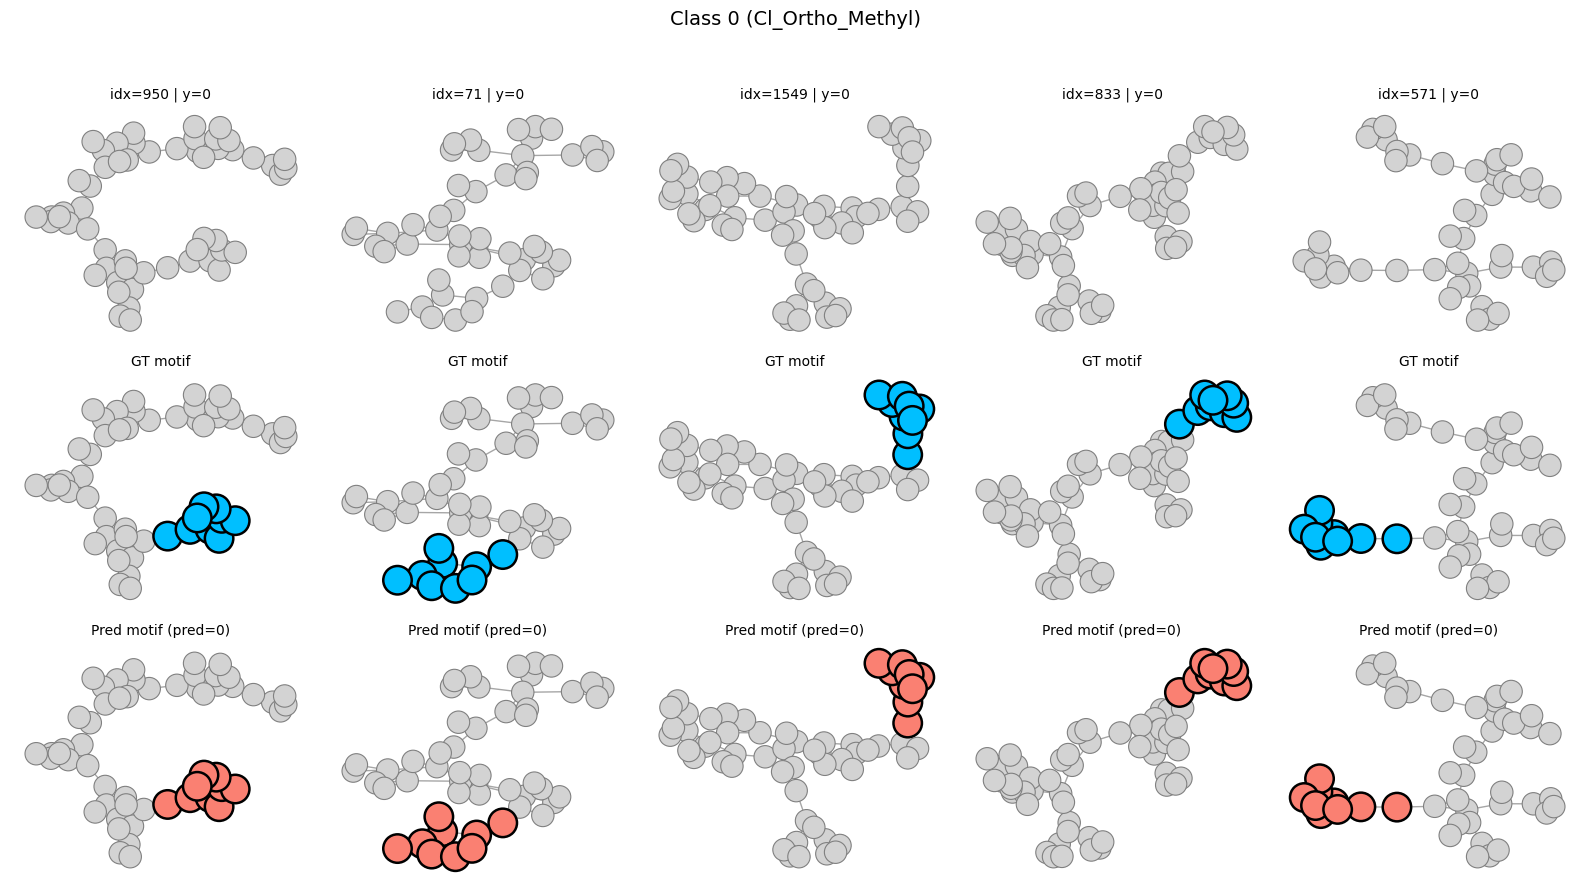

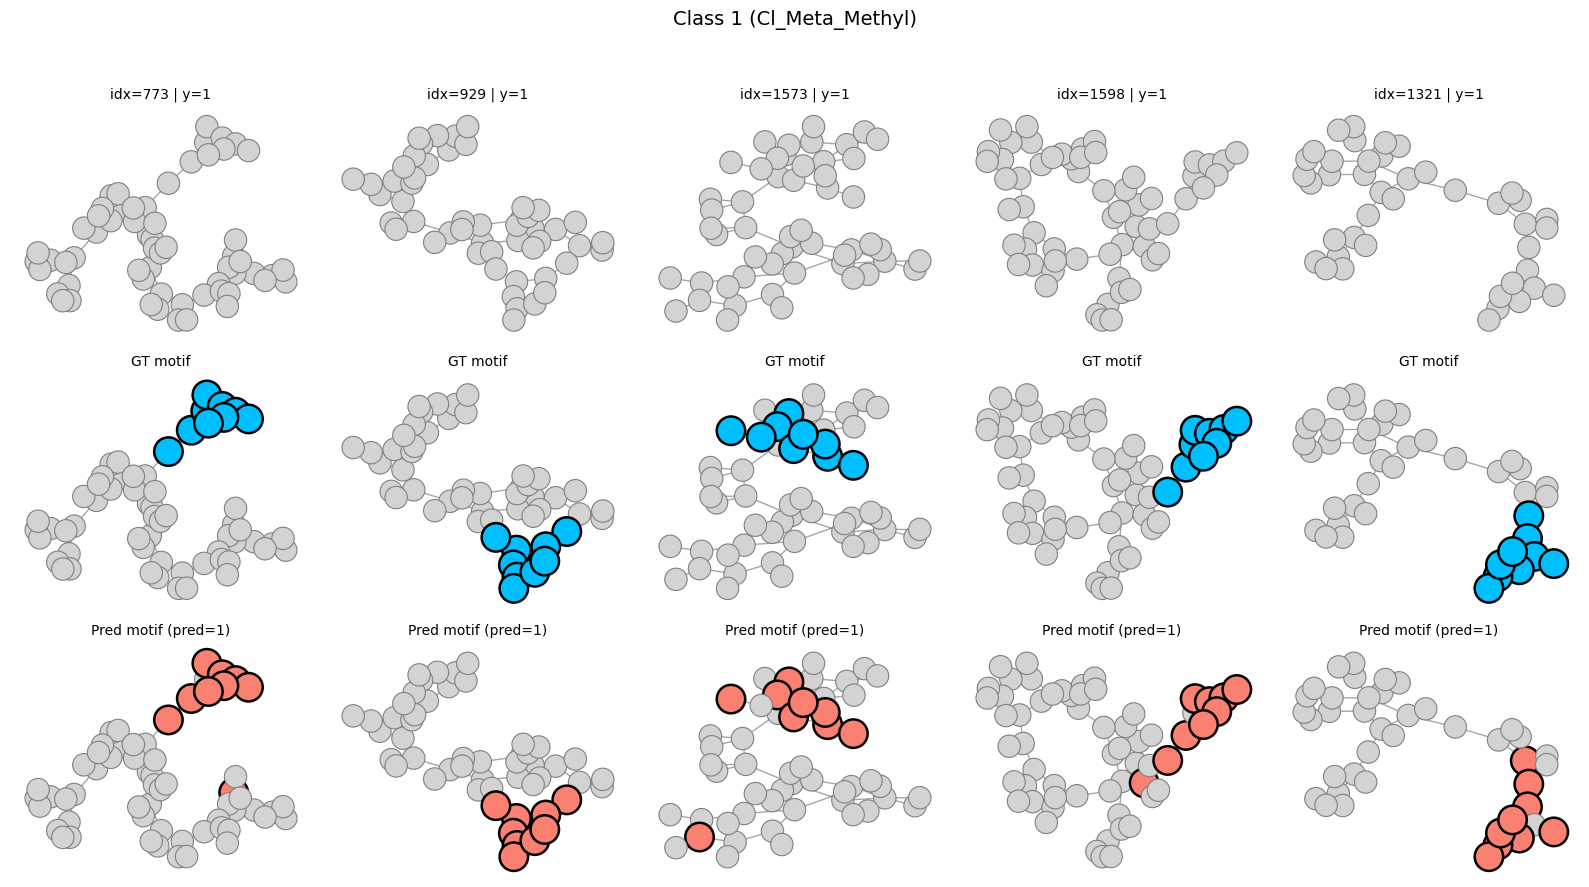

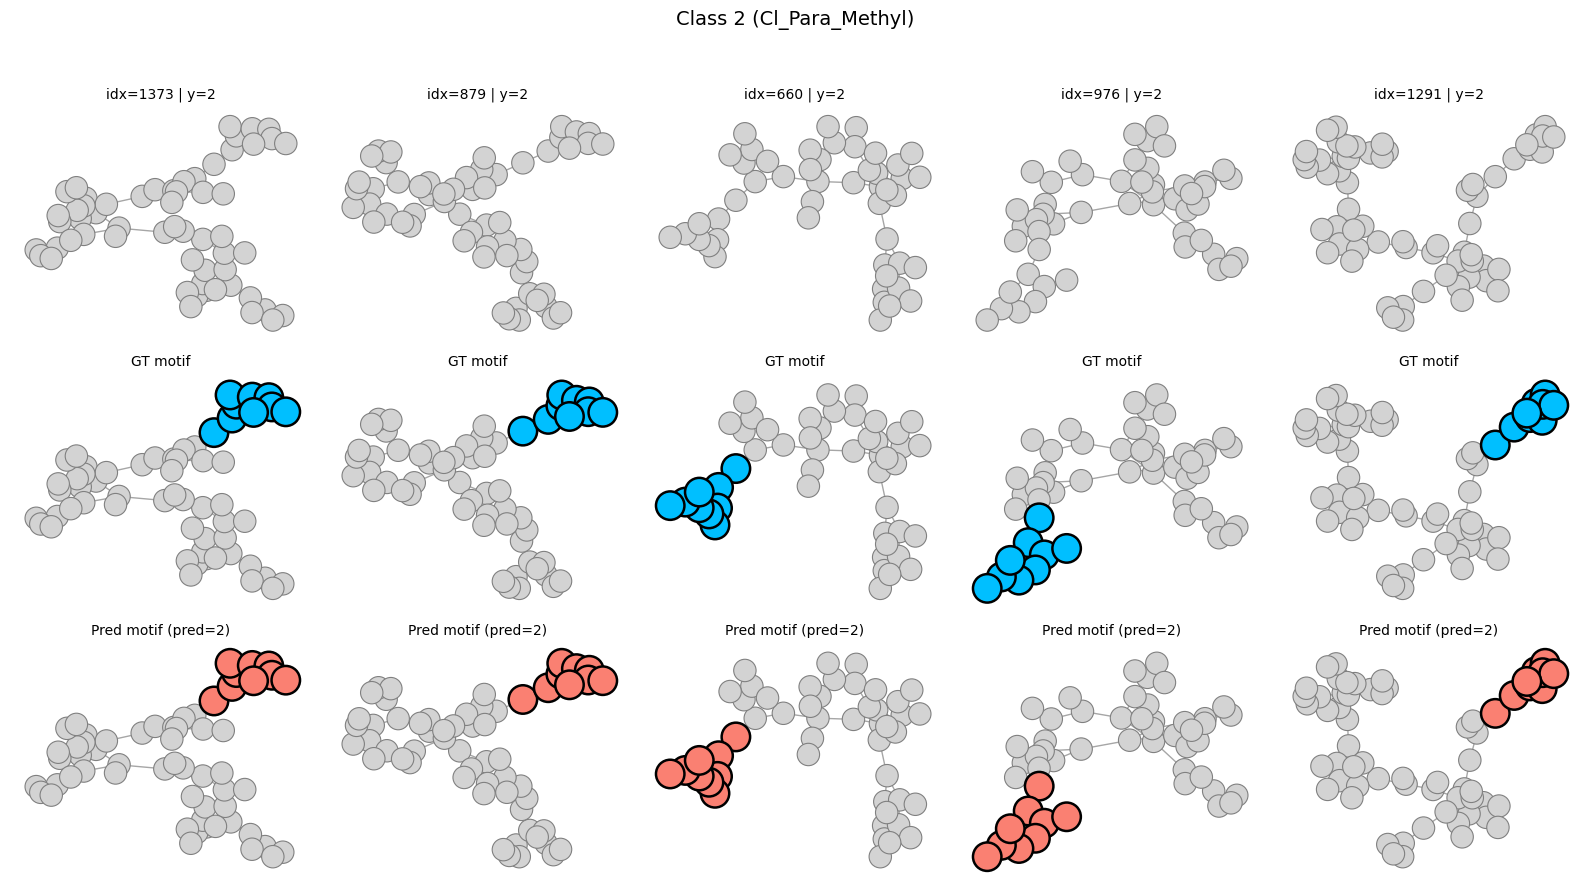

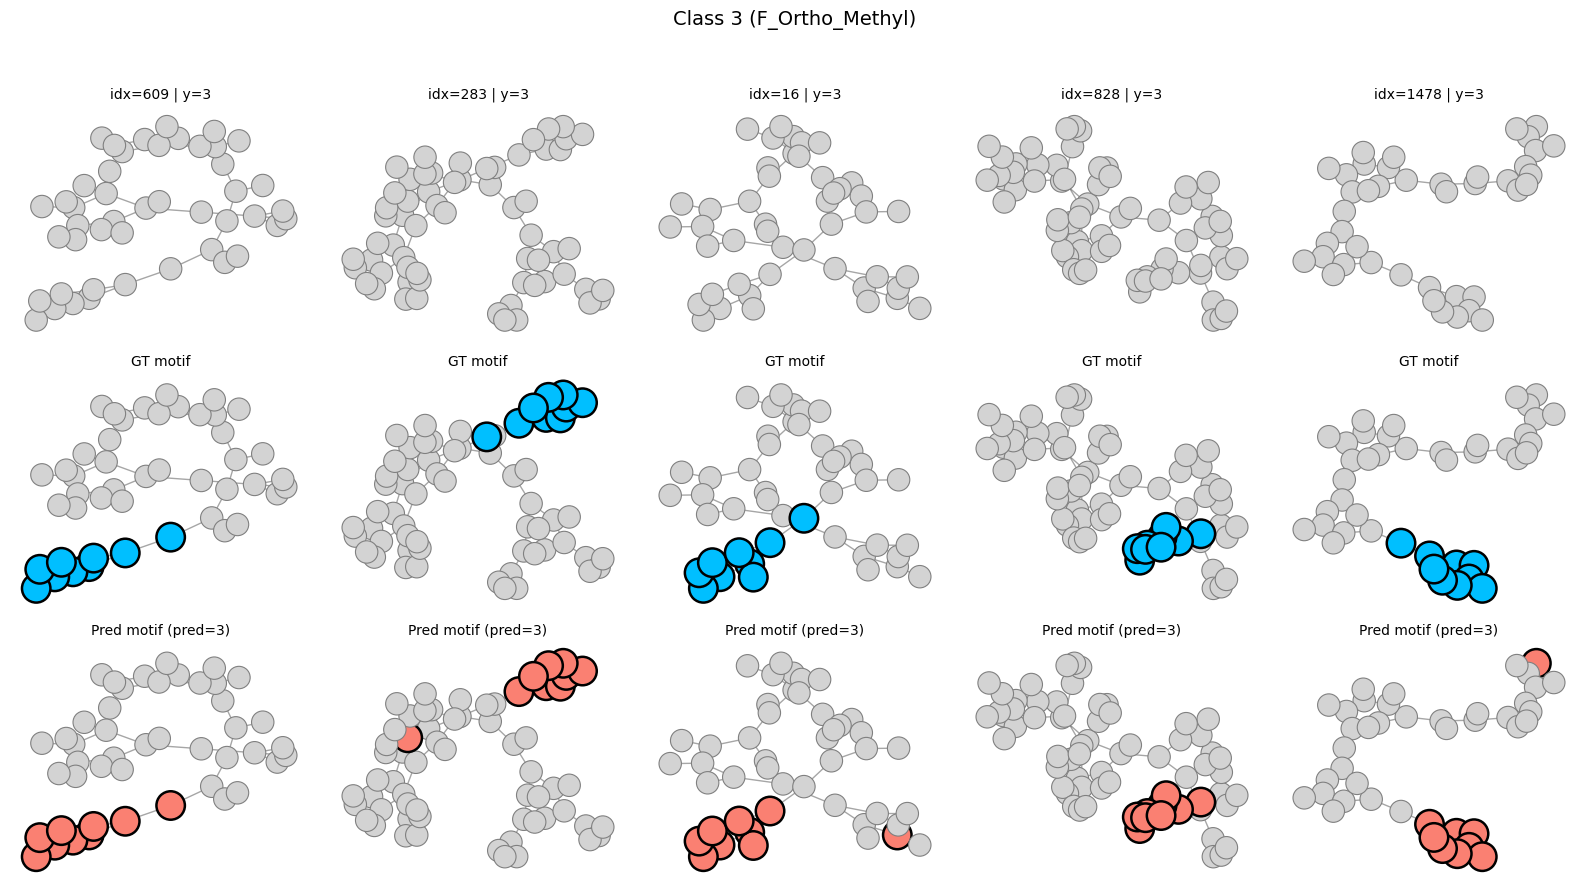

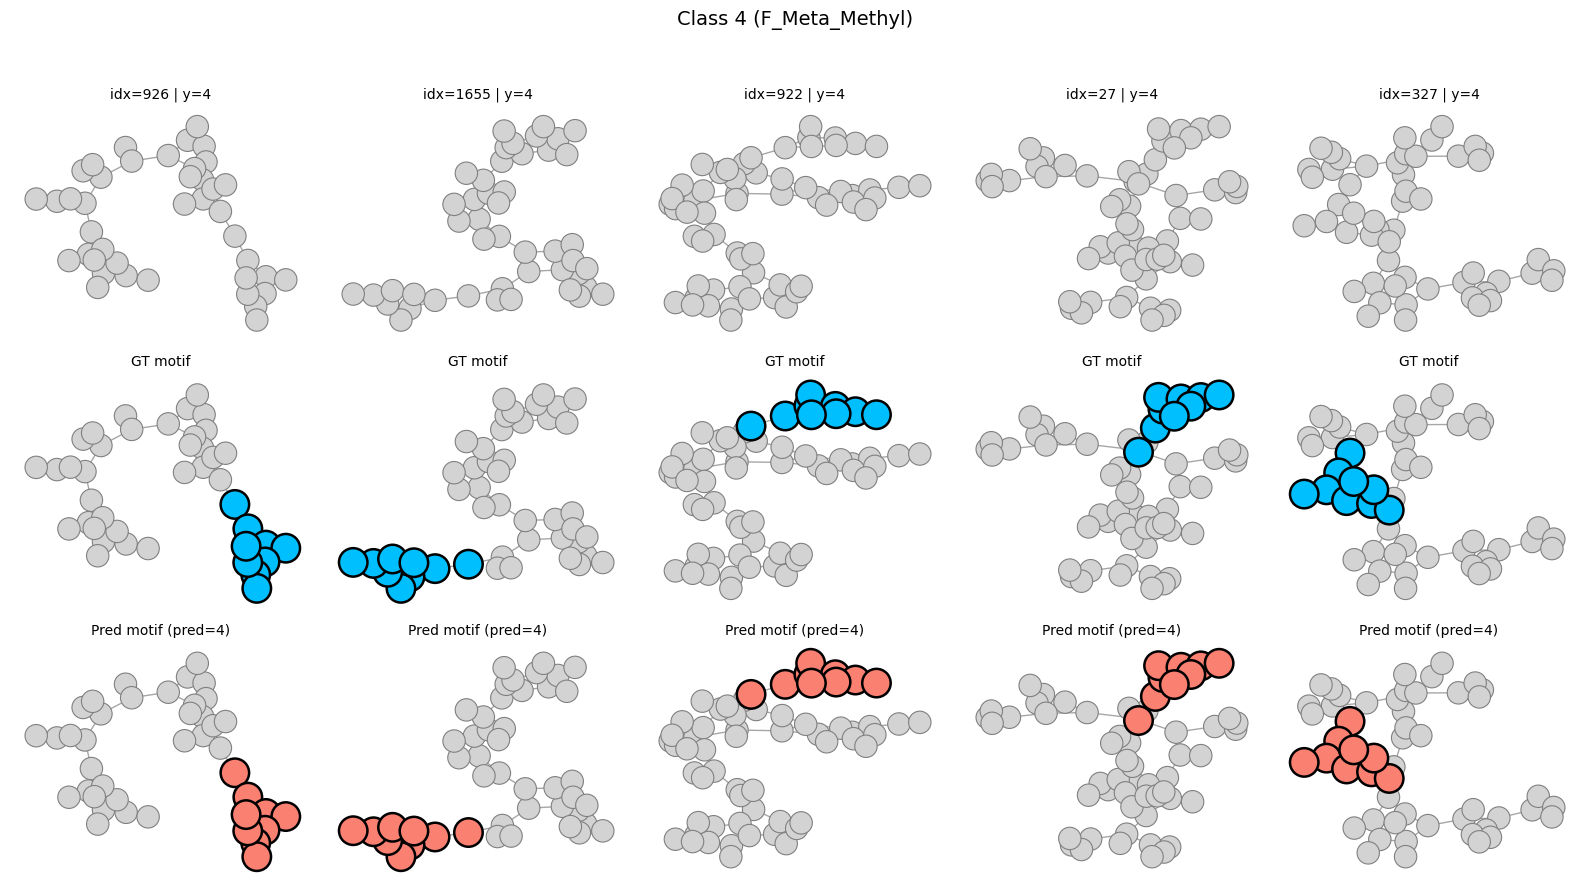

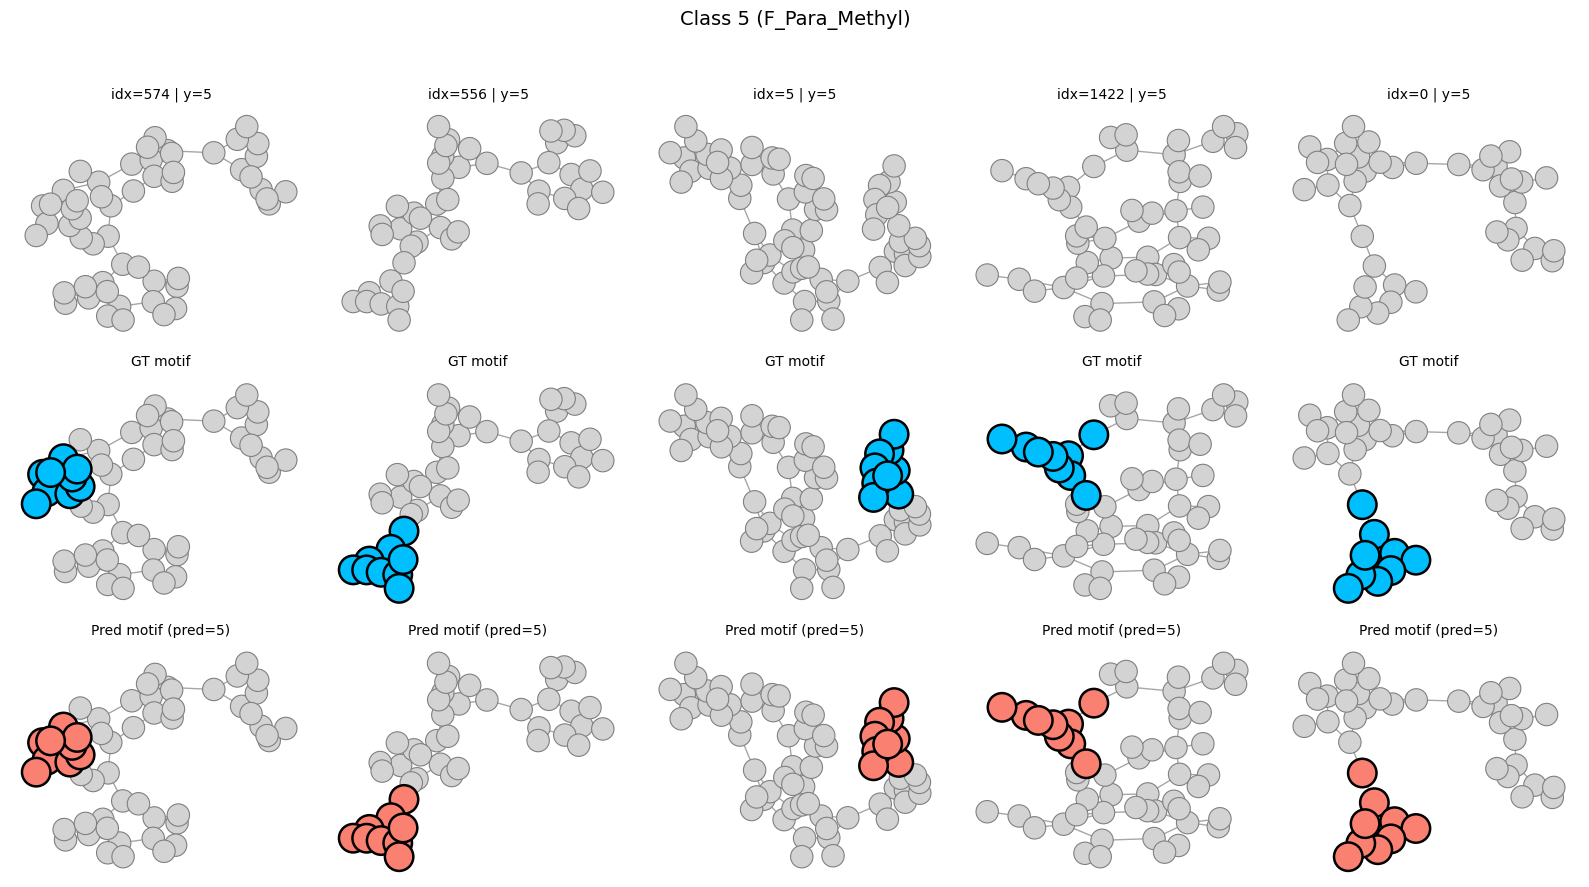

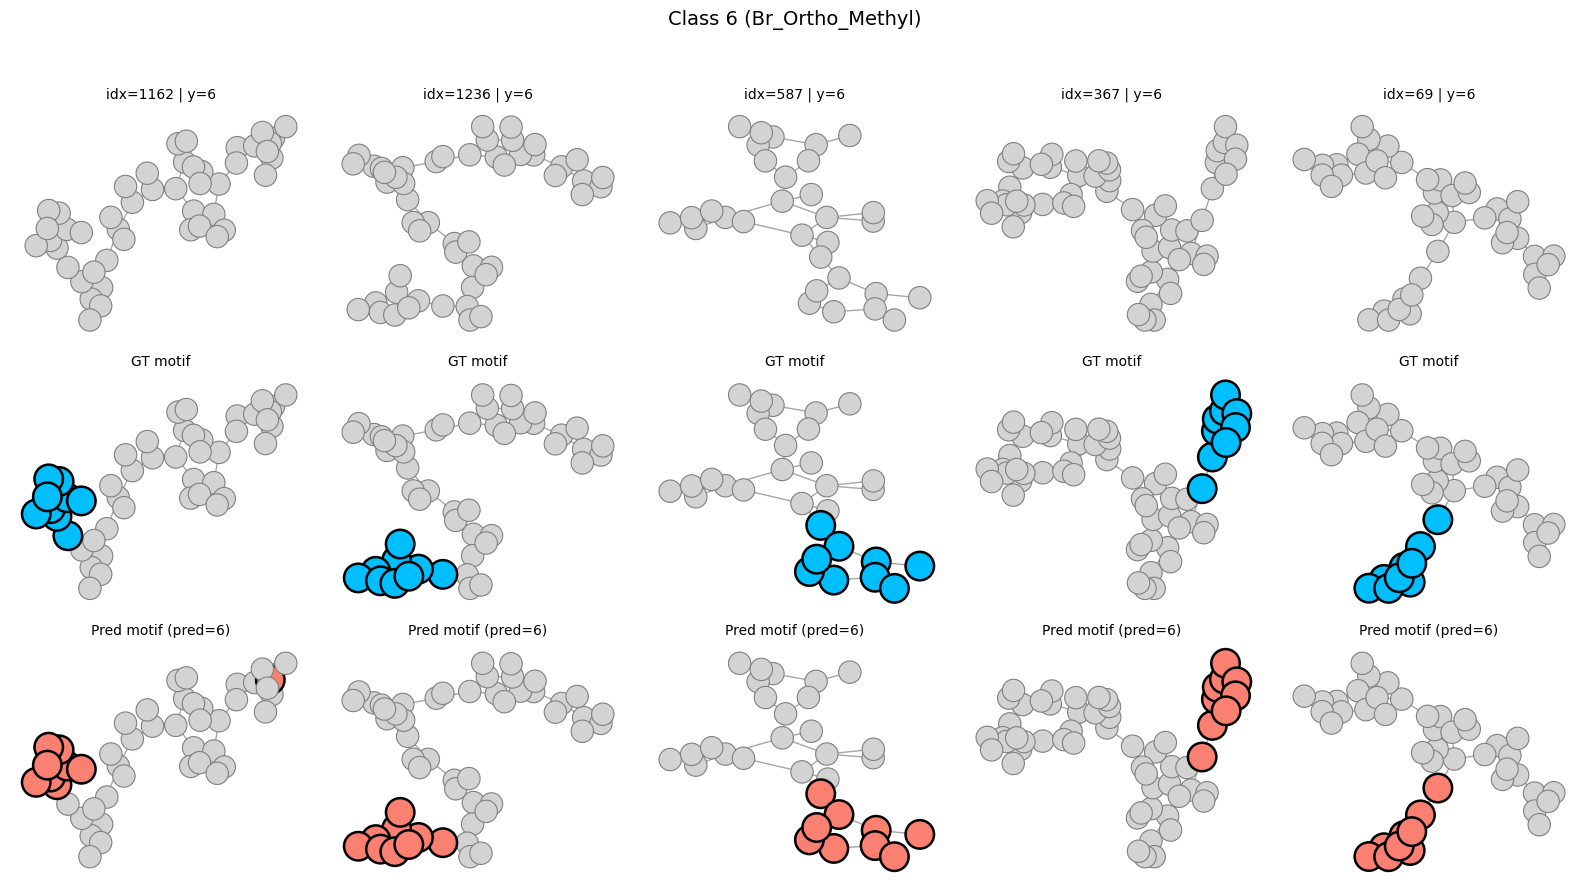

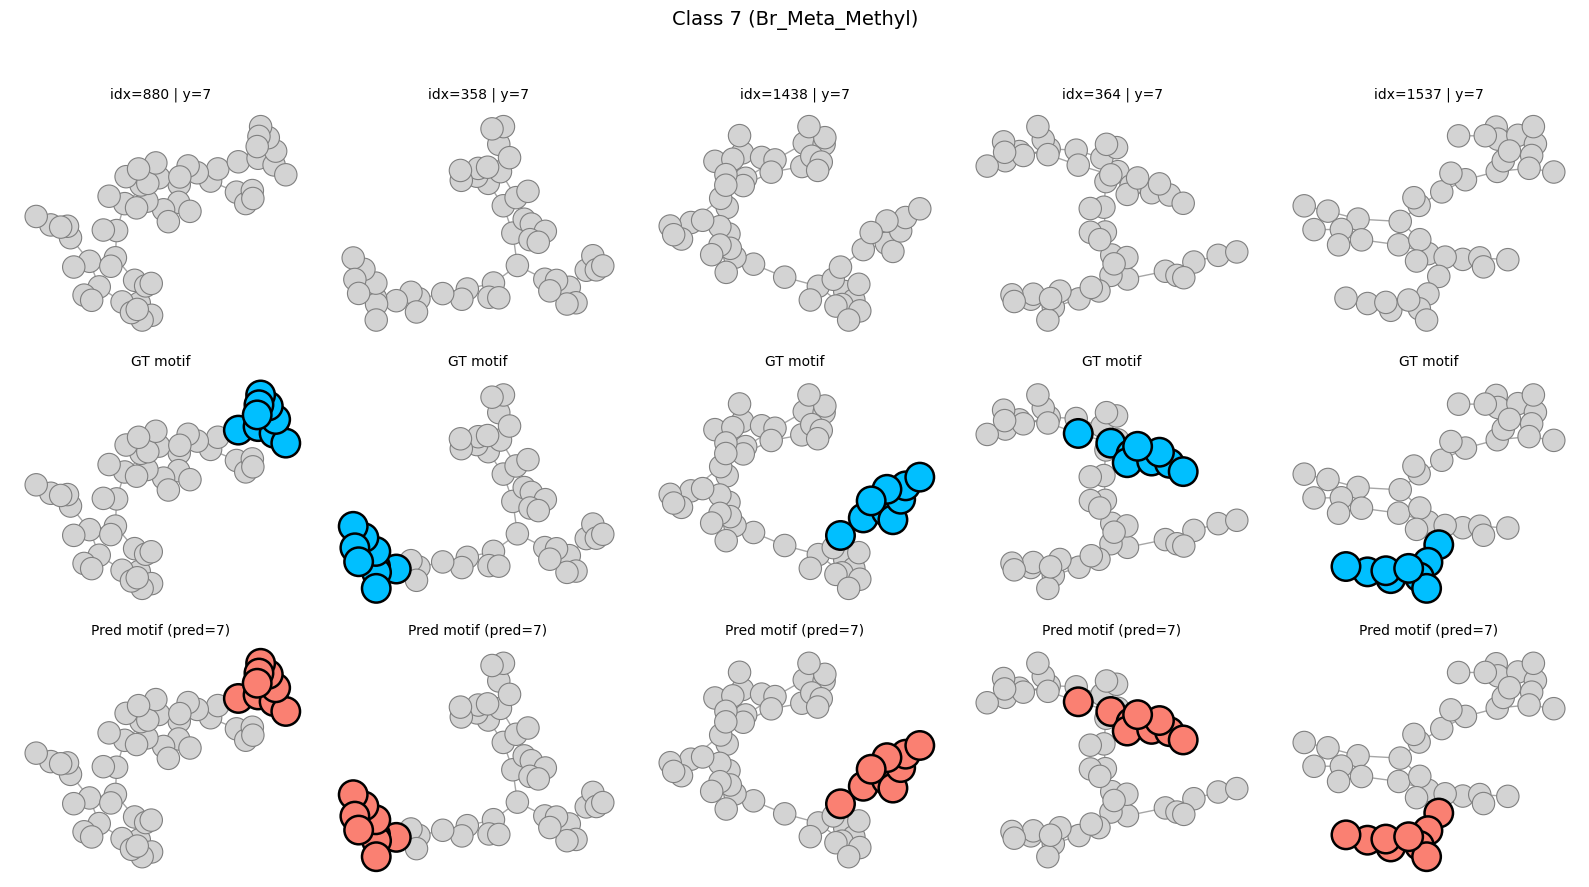

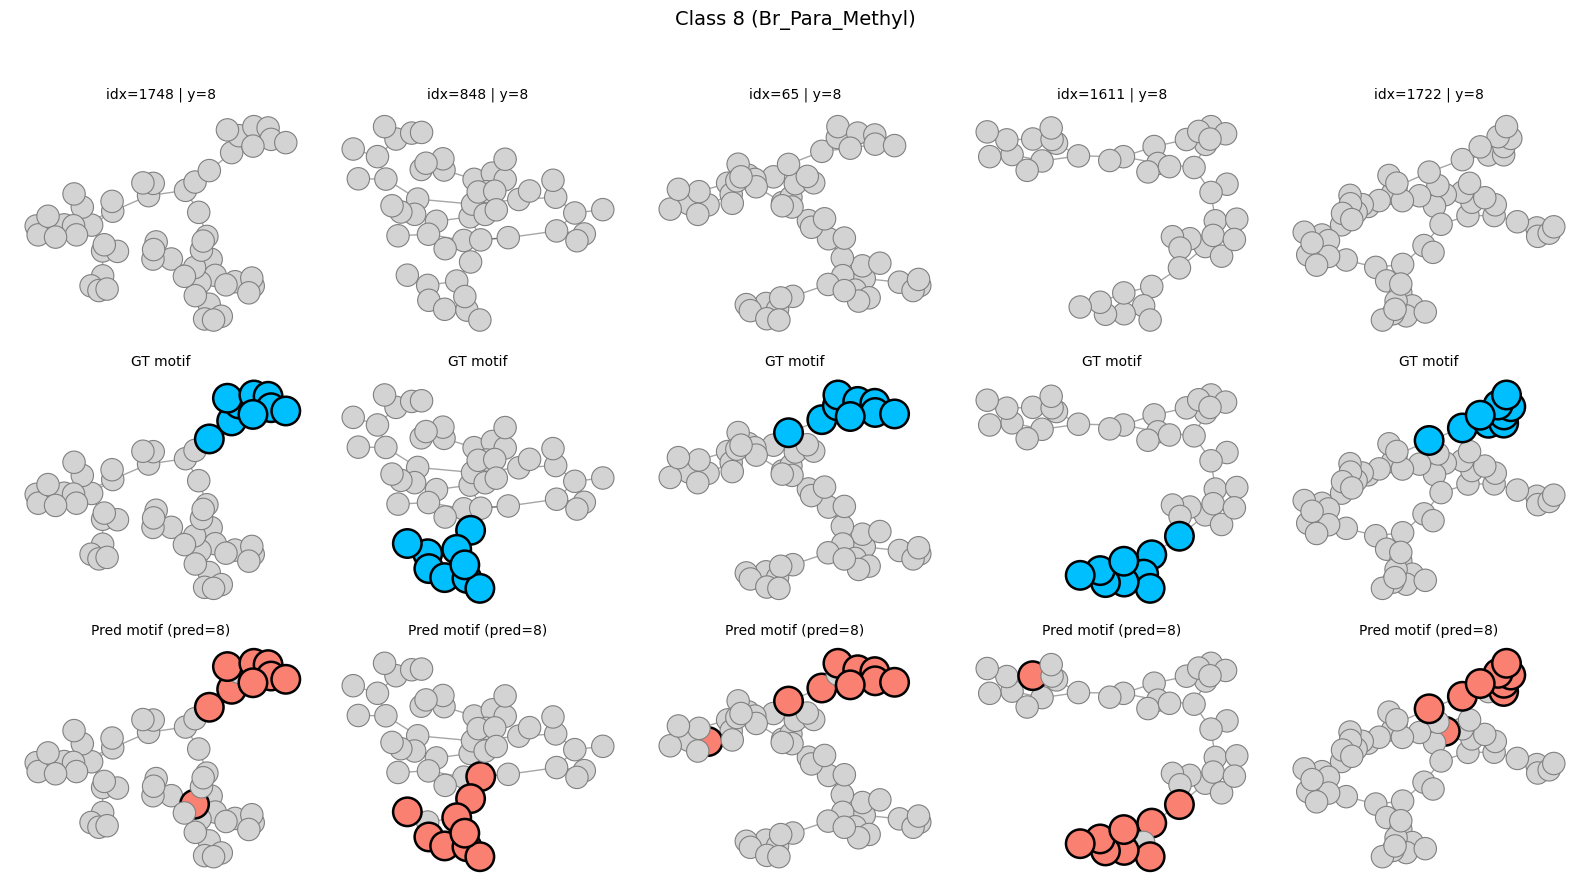

In [21]:
# Consolidated visualization: per class
# Row 1: 5 original graphs
# Row 2: GT motif highlighted
# Row 3: Predicted motif highlighted (top-k by attribution)
#
# Assumes you have: test_ds (list of PyG Data), final_model, DEVICE,
# explain_edge_attr (from bcosgnn.explain_edge_attr), node_scores_from_contrib(scores from contrib["x"])
# and each Data has data.explanation_mask (0/1 per node).

import numpy as np
import torch
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx


# -------------------------
# Helpers
# -------------------------
def _y_int(d):
    y = d.y
    if torch.is_tensor(y):
        return int(y.view(-1)[0].item())
    return int(y)


def _bool_mask(m, n):
    if m is None:
        return np.zeros(n, dtype=bool)
    if torch.is_tensor(m):
        m = m.detach().cpu().numpy()
    m = np.asarray(m).astype(bool)
    if m.shape[0] != n:
        m = m.reshape(-1)[:n]
    return m


def _graph_pos_and_edges(d):
    G = to_networkx(d, to_undirected=True)
    pos = nx.spring_layout(G, seed=0)  # deterministic layout
    return G, pos


def _draw_graph(ax, d, G, pos, title=None, highlight=None, highlight_color="deepskyblue"):
    n = int(d.num_nodes)
    base_sizes = np.full(n, 260.0)
    node_face = ["lightgray"] * n
    edgecolors = ["gray"] * n
    linewidths = [0.8] * n

    if highlight is not None:
        highlight = np.asarray(highlight, dtype=bool)
        for i in range(n):
            if highlight[i]:
                node_face[i] = highlight_color
                edgecolors[i] = "black"
                linewidths[i] = 1.8
                base_sizes[i] = 420.0

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.35, width=1.0)
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=base_sizes,
        node_color=node_face,
        edgecolors=edgecolors,
        linewidths=linewidths,
    )

    ax.set_axis_off()
    if title:
        ax.set_title(title, fontsize=10)


def _explain_topk_mask(model, d, target_class=None, topk_mode="gt", fixed_k=10):
    # Returns pred_class, scores(np), pred_mask(np bool)
    d = d.to(DEVICE)
    d.batch = torch.zeros(d.x.size(0), dtype=torch.long, device=DEVICE)

    model.eval()
    with torch.no_grad():
        logits = model(d.x, d.edge_index, d.edge_attr, d.batch)
        pred_class = int(logits.argmax(dim=-1).item())

    if target_class is None:
        target_class = pred_class

    contrib = explain_edge_attr(
        model,
        d.x,
        d.edge_index,
        d.edge_attr,
        d.batch,
        target=target_class,
    )
    scores = node_scores_from_contrib(contrib["x"])  # np.ndarray [num_nodes]

    gt = _bool_mask(getattr(d, "explanation_mask", None), d.x.size(0))
    if topk_mode == "gt":
        k = int(gt.sum())
        if k <= 0:
            k = min(fixed_k, len(scores))
    else:
        k = int(fixed_k)

    idx = np.argsort(scores)[-k:]
    pred_mask = np.zeros(len(scores), dtype=bool)
    pred_mask[idx] = True
    return pred_class, scores, pred_mask


def _pick_5_per_class(test_ds, num_classes, seed=0):
    rng = np.random.default_rng(seed)
    idx_by_c = [[] for _ in range(num_classes)]
    for i, d in enumerate(test_ds):
        idx_by_c[_y_int(d)].append(i)

    picks = {}
    for c in range(num_classes):
        arr = np.array(idx_by_c[c], dtype=int)
        rng.shuffle(arr)
        picks[c] = arr[: min(5, len(arr))].tolist()
    return picks


# -------------------------
# Main
# -------------------------
NUM_CLASSES = int(max(_y_int(d) for d in test_ds) + 1)
SEED_VIS = 0
TOPK_MODE = "gt"   # use k = (#GT nodes). Set to "fixed" to use FIXED_K
FIXED_K = 10

# Optional pretty class names if you have motifs dict like {0:(..., 'Cl_Ortho'), ...}
CLASS_NAMES = None
try:
    CLASS_NAMES = {k: v[1] for k, v in motifs.items()}
except Exception:
    pass

picks = _pick_5_per_class(test_ds, NUM_CLASSES, seed=SEED_VIS)

for c in range(NUM_CLASSES):
    idxs = picks.get(c, [])
    if len(idxs) == 0:
        print(f"Class {c}: no test examples")
        continue

    fig, axes = plt.subplots(3, 5, figsize=(16, 9))
    fig.suptitle(f"Class {c} ({CLASS_NAMES.get(c, c) if CLASS_NAMES else c})", fontsize=14)

    # Precompute layouts per graph so all rows align visually
    layouts = []
    datas = []
    for j, idx in enumerate(idxs):
        d = test_ds[idx].cpu()
        G, pos = _graph_pos_and_edges(d)
        layouts.append((G, pos))
        datas.append(d)

    # Fill unused columns if < 5
    for col in range(5):
        if col >= len(datas):
            for r in range(3):
                axes[r, col].set_axis_off()

    # Row 1: originals
    for col, (d, (G, pos)) in enumerate(zip(datas, layouts)):
        _draw_graph(
            axes[0, col], d, G, pos,
            title=f"idx={idxs[col]} | y={_y_int(d)}",
            highlight=None
        )

    # Row 2: GT highlighted
    for col, (d, (G, pos)) in enumerate(zip(datas, layouts)):
        gt = _bool_mask(getattr(d, "explanation_mask", None), d.num_nodes)
        _draw_graph(
            axes[1, col], d, G, pos,
            title="GT motif",
            highlight=gt,
            highlight_color="deepskyblue"
        )

    # Row 3: Predicted highlighted (top-k attribution)
    for col, (d, (G, pos)) in enumerate(zip(datas, layouts)):
        pred_class, scores, pred_mask = _explain_topk_mask(
            final_model, d,
            target_class=c,   # explain wrt this class
            topk_mode=TOPK_MODE,
            fixed_k=FIXED_K
        )
        _draw_graph(
            axes[2, col], d, G, pos,
            title=f"Pred motif (pred={pred_class})",
            highlight=pred_mask,
            highlight_color="salmon"
        )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import networkx as nx
from collections import deque
from torch_geometric.utils import to_networkx

# -------------------------
# Utilities (Logic Unchanged)
# -------------------------
def _y_int(d):
    y = d.y
    return int(y.view(-1)[0].item()) if torch.is_tensor(y) else int(y)

def _bool_mask(m, n):
    if m is None:
        return np.zeros(n, dtype=bool)
    if torch.is_tensor(m):
        m = m.detach().cpu().numpy()
    m = np.asarray(m).astype(bool).reshape(-1)
    if len(m) != n:
        m = m[:n]
    return m

def _adj_from_edge_index(edge_index, n):
    adj = [[] for _ in range(n)]
    ei = edge_index.detach().cpu().numpy()
    for u, v in ei.T:
        u = int(u); v = int(v)
        adj[u].append(v)
    return adj

def _bfs_shortest_path(adj, src, dst):
    if src == dst:
        return [src]
    q = deque([src])
    prev = {src: None}
    while q:
        u = q.popleft()
        for v in adj[u]:
            if v in prev:
                continue
            prev[v] = u
            if v == dst:
                q.clear()
                break
            q.append(v)
    if dst not in prev:
        return None
    path = []
    cur = dst
    while cur is not None:
        path.append(cur)
        cur = prev[cur]
    path.reverse()
    return path

def _safe_atom_index(symbol):
    try:
        # Assumes get_one_hot_atom is available in your scope
        v = np.asarray(get_one_hot_atom(symbol), dtype=float)
        return int(np.argmax(v))
    except Exception:
        return None

IDX = {
    "C": _safe_atom_index("C"),
    "F": _safe_atom_index("F"),
    "Cl": _safe_atom_index("Cl"),
    "Br": _safe_atom_index("Br"),
}

# Full atom vocab used by get_one_hot_atom (for readable node labels)
ATOM_VOCAB = ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P']
IDX_TO_SYM = {}
for _sym in ATOM_VOCAB:
    _idx = _safe_atom_index(_sym)
    if _idx is not None:
        IDX_TO_SYM[_idx] = _sym

def _node_symbol_from_x(d, i):
    x = d.x
    if torch.is_tensor(x):
        j = int(x[i].detach().cpu().argmax().item())
    else:
        j = int(np.asarray(x[i]).argmax())
    return IDX_TO_SYM.get(j, "?")

def _node_is_symbol(d, i, sym):
    idx = IDX.get(sym, None)
    if idx is None:
        return False
    x = d.x
    if torch.is_tensor(x):
        return bool(x[i, idx].detach().cpu().item() > 0.5)
    return bool(x[i, idx] > 0.5)

def _node_symbol_guess(d, i):
    return _node_symbol_from_x(d, i)

def _pick_5_per_class(test_ds, num_classes, seed=0):
    rng = np.random.default_rng(seed)
    idx_by_c = [[] for _ in range(num_classes)]
    for i, d in enumerate(test_ds):
        idx_by_c[_y_int(d)].append(i)
    picks = {}
    for c in range(num_classes):
        arr = np.array(idx_by_c[c], dtype=int)
        rng.shuffle(arr)
        picks[c] = arr[: min(5, len(arr))].tolist()
    return picks


# -------------------------
# Motif Logic
# -------------------------
def _halogen_nodes(d):
    n = d.num_nodes
    h = []
    for i in range(n):
        if _node_is_symbol(d, i, "Cl") or _node_is_symbol(d, i, "Br") or _node_is_symbol(d, i, "F"):
            h.append(i)
    return h

def _attachment_carbon(adj, d, halogen_node):
    neigh = adj[halogen_node]
    if not neigh:
        return None
    for v in neigh:
        if _node_is_symbol(d, v, "C"):
            return v
    return neigh[0]

def _position_path_mask_from_halogen_pair(d, h1, h2):
    n = d.num_nodes
    adj = _adj_from_edge_index(d.edge_index, n)
    a1 = _attachment_carbon(adj, d, h1)
    a2 = _attachment_carbon(adj, d, h2)
    if a1 is None or a2 is None:
        return None, None, None

    path = _bfs_shortest_path(adj, a1, a2)
    if path is None:
        return None, None, None

    mask = np.zeros(n, dtype=bool)
    for p in path:
        mask[int(p)] = True
    mask[int(h1)] = True
    mask[int(h2)] = True
    return mask, path, (a1, a2)

def _gt_position_mask(d):
    n = d.num_nodes
    gt = _bool_mask(getattr(d, "explanation_mask", None), n)
    if not gt.any():
        return None, None

    hal = [i for i in range(n) if gt[i] and (_node_is_symbol(d, i, "Cl") or _node_is_symbol(d, i, "Br") or _node_is_symbol(d, i, "F"))]
    if len(hal) < 2:
        return gt, None

    h1, h2 = hal[0], hal[1]
    pmask, path, _ = _position_path_mask_from_halogen_pair(d, h1, h2)
    return (pmask if pmask is not None else gt), path

def _pred_position_mask_from_scores(d, scores):
    hal = _halogen_nodes(d)
    if len(hal) < 2:
        return None, None

    hal = sorted(hal, key=lambda i: float(scores[i]), reverse=True)
    h1, h2 = hal[0], hal[1]

    pmask, path, anchors = _position_path_mask_from_halogen_pair(d, h1, h2)
    return pmask, (h1, h2, anchors, path)

def _explain_scores(final_model, d, target_class):
    d = d.to(DEVICE)
    d.batch = torch.zeros(d.x.size(0), dtype=torch.long, device=DEVICE)
    final_model.eval()
    with torch.no_grad():
        logits = final_model(d.x, d.edge_index, d.edge_attr, d.batch)
        pred = int(logits.argmax(dim=-1).item())
    contrib = explain_edge_attr(final_model, d.x, d.edge_index, d.edge_attr, d.batch, target=int(target_class))
    scores = node_scores_from_contrib(contrib["x"])
    return pred, scores


# -------------------------
# Improved Layout & Drawing
# -------------------------
def _layout(d):
    G = to_networkx(d, to_undirected=True)
    # Kamada-Kawai gives the best "chemical structure" look
    try:
        pos = nx.kamada_kawai_layout(G, scale=2.0)
    except Exception:
        pos = nx.spring_layout(G, seed=42, k=0.5)
    return G, pos

def _draw(ax, d, G, pos, title="", highlight_path=None, highlight_hal=None,
          path_color="#4daf4a", hal_color="#e41a1c"):
    """
    Cleaner drawing function for print.
    - path_color: Color for the structural path (default: Green)
    - hal_color: Color for the specific atoms/halogens (default: Red)
    """
    n = d.num_nodes

    # 1. Setup Base Styles (Unimportant nodes)
    # Using 'whitesmoke' or very light grey for non-active nodes saves ink and reduces noise
    node_colors = ["#f0f0f0"] * n
    node_sizes = [200] * n  # Smaller default size
    node_borders = ["#cccccc"] * n
    border_widths = [1.0] * n

    # Edges
    edge_colors = ["#e0e0e0"] * G.number_of_edges()
    edge_widths = [1.0] * G.number_of_edges()

    # 2. Logic to highlight specific nodes/edges
    # We create a specific list for highlighted edges to draw them ON TOP
    highlighted_edges = []

    # Helper to check if node i is highlighted
    is_path = np.zeros(n, dtype=bool)
    if highlight_path is not None:
        is_path = np.asarray(highlight_path, dtype=bool)

    is_hal = np.zeros(n, dtype=bool)
    if highlight_hal is not None:
        is_hal = np.asarray(highlight_hal, dtype=bool)

    # Update Node Styles
    for i in range(n):
        if is_hal[i]:
            node_colors[i] = hal_color
            node_sizes[i] = 450
            node_borders[i] = "#333333"  # Dark grey border
            border_widths[i] = 2.0
        elif is_path[i]:
            node_colors[i] = path_color
            node_sizes[i] = 350
            node_borders[i] = "#333333"
            border_widths[i] = 1.5

    # Update Edge Styles (Color edges if both endpoints are in the mask)
    edges_list = list(G.edges())
    edge_color_list = []
    edge_width_list = []

    for u, v in edges_list:
        # If both nodes are part of the path/halogens, highlight the edge
        if (is_path[u] or is_hal[u]) and (is_path[v] or is_hal[v]):
            edge_color_list.append("#555555")  # Dark grey for the path
            edge_width_list.append(2.0)
        else:
            edge_color_list.append("#e0e0e0")  # Faint grey for context
            edge_width_list.append(0.8)

    # 3. Draw Sequence (Z-Order is crucial for neatness)

    # A. Draw Edges
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edgelist=edges_list,
        edge_color=edge_color_list,
        width=edge_width_list,
        alpha=0.9
    )

    # B. Draw Nodes
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        nodelist=range(n),
        node_size=node_sizes,
        node_color=node_colors,
        edgecolors=node_borders,
        linewidths=border_widths,
    )

    # C. Draw Labels (Only highlighted nodes to reduce clutter)
    labels = {}
    for i in range(n):
        if is_hal[i] or is_path[i]:
            labels[i] = _node_symbol_guess(d, i)

    nx.draw_networkx_labels(
        G, pos, labels=labels, font_size=10, ax=ax, font_weight='bold'
    )

    # Remove axis box
    ax.set_axis_off()

    # Clean Title
    ax.set_title(title, fontsize=10, y=0.95)


# -------------------------
# Main Execution
# -------------------------
_required = [
    "test_ds",
    "final_model",
    "DEVICE",
    "motifs",
    "explain_edge_attr",
    "node_scores_from_contrib",
]
_missing = [k for k in _required if k not in globals()]

if _missing:
    print(
        "Skipping visualization cell because required variables are missing: "
        + ", ".join(_missing)
        + ".\nRun the earlier setup/training cells first, then re-run this cell."
    )
else:
    NUM_CLASSES = int(max(_y_int(d) for d in test_ds) + 1)
    SEED_VIS = 0

    # Optional: Load class names if available
    CLASS_NAMES = None
    try:
        CLASS_NAMES = {k: v[1] for k, v in motifs.items()}
    except Exception:
        pass

    picks = _pick_5_per_class(test_ds, NUM_CLASSES, seed=SEED_VIS)

    for c in range(NUM_CLASSES):
        idxs = picks.get(c, [])
        if len(idxs) == 0:
            continue

        # Increase Figure Size and DPI for print quality
        fig, axes = plt.subplots(3, 5, figsize=(20, 10), dpi=300)

        cls_name = CLASS_NAMES.get(c, str(c)) if CLASS_NAMES else str(c)
        fig.suptitle(f"Class {c}: {cls_name}", fontsize=16, fontweight='bold', y=0.98)

        datas = []
        layouts = []
        for idx in idxs:
            d = test_ds[idx].cpu()
            G, pos = _layout(d)
            datas.append(d)
            layouts.append((G, pos))

        # Handle empty columns
        for col in range(5):
            if col >= len(datas):
                for r in range(3):
                    axes[r, col].remove()  # Completely remove axis
                continue

            idx = idxs[col]
            d = datas[col]
            G, pos = layouts[col]

            # -----------------------------
            # Row 1: Original Graph (Context)
            # -----------------------------
            _draw(axes[0, col], d, G, pos, title=f"Example {idx}\n(True y={_y_int(d)})")

            # -----------------------------
            # Row 2: Ground Truth (Blue/Green Theme)
            # -----------------------------
            gt_mask, gt_path = _gt_position_mask(d)
            gt_hal = np.zeros(d.num_nodes, dtype=bool)
            for i in range(d.num_nodes):
                if gt_mask is not None and gt_mask[i] and (_node_symbol_guess(d, i) in ["Cl", "Br", "F"]):
                    gt_hal[i] = True

            _draw(
                axes[1, col], d, G, pos,
                title="Ground Truth Motif",
                highlight_path=(gt_mask if gt_mask is not None else None),
                highlight_hal=gt_hal,
                path_color="#a6cee3",  # Light Blue
                hal_color="#1f78b4",   # Dark Blue
            )

            # -----------------------------
            # Row 3: Model Prediction (Red Theme)
            # -----------------------------
            pred_class, scores = _explain_scores(final_model, d, target_class=c)
            pmask, meta = _pred_position_mask_from_scores(d, scores)

            if pmask is None:
                # Fallback for display
                n = d.num_nodes
                k = int(gt_mask.sum()) if gt_mask is not None else min(5, n)
                top_idx = np.argsort(scores)[-k:]
                pmask = np.zeros(n, dtype=bool); pmask[top_idx] = True
                phal = np.zeros(n, dtype=bool)
            else:
                h1, h2, anchors, path = meta
                phal = np.zeros(d.num_nodes, dtype=bool)
                phal[h1] = True
                phal[h2] = True

            _draw(
                axes[2, col], d, G, pos,
                title=f"Prediction (Pred={pred_class})",
                highlight_path=pmask,
                highlight_hal=phal,
                path_color="#fb9a99",  # Light Red
                hal_color="#e31a1c",   # Dark Red
            )

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()


NameError: name 'test_ds' is not defined

### Faithfulness check (Deletion/Insertion)

This cell measures whether removing the top-attributed nodes hurts the model more than removing random nodes (deletion), and whether adding back top-attributed nodes helps more than random nodes (insertion).

In [ ]:
import numpy as np
import torch


def _mask_nodes_x(d, node_idx, mode="zero"):
    dd = d.clone()
    x = dd.x.clone()
    
    if isinstance(node_idx, np.ndarray):
        node_idx = np.ascontiguousarray(node_idx)
    
    idx = torch.as_tensor(node_idx, device=x.device, dtype=torch.long)
    if mode == "zero":
        x[idx] = 0
    elif mode == "mean":
        mu = x.mean(dim=0, keepdim=True)
        x[idx] = mu
    else:
        raise ValueError("mode must be 'zero' or 'mean'")
    dd.x = x
    return dd

def faithfulness_deletion_insertion(
    model,
    ds,
    n_graphs=50,
    frac=0.2,
    seed=0,
    target_mode="pred",   # 'pred' or 'true'
    mask_mode="zero",    # 'zero' or 'mean'
):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(ds), size=min(n_graphs, len(ds)), replace=False)

    drops_expl, drops_rand = [], []
    gains_expl, gains_rand = [], []

    for ii in idxs:
        d0 = ds[int(ii)]
        logits0 = _single_graph_logits(model, d0)
        pred = int(logits0.argmax().item())
        true = int(d0.y.view(-1)[0].item()) if torch.is_tensor(d0.y) else int(d0.y)
        target = pred if target_mode == "pred" else true

        scores = _scores_for_target(model, d0, target)
        n = int(d0.num_nodes)
        k = max(1, int(round(frac * n)))

        order = np.argsort(scores)[::-1]
        topk = order[:k]
        randk = rng.choice(n, size=k, replace=False)

        base = float(logits0[target].item())

        # Deletion
        d_del_expl = _mask_nodes_x(d0, topk, mode=mask_mode)
        d_del_rand = _mask_nodes_x(d0, randk, mode=mask_mode)
        del_expl = float(_single_graph_logits(model, d_del_expl)[target].item())
        del_rand = float(_single_graph_logits(model, d_del_rand)[target].item())
        drops_expl.append(base - del_expl)
        drops_rand.append(base - del_rand)

        # Insertion
        d_base = d0.clone()
        xb = d_base.x.clone()
        if mask_mode == "zero":
            xb[:] = 0
        else:
            xb[:] = xb.mean(dim=0, keepdim=True)
        d_base.x = xb

        def _insert(dd, node_idx):
            dd = dd.clone()
            x = dd.x.clone()
            orig = d0.x.to(x.device)
            if isinstance(node_idx, np.ndarray):
                node_idx = np.ascontiguousarray(node_idx)
            idx = torch.as_tensor(node_idx, device=x.device, dtype=torch.long)
            x[idx] = orig[idx]
            dd.x = x
            return dd

        d_ins_expl = _insert(d_base, topk)
        d_ins_rand = _insert(d_base, randk)
        ins_base = float(_single_graph_logits(model, d_base)[target].item())
        ins_expl = float(_single_graph_logits(model, d_ins_expl)[target].item())
        ins_rand = float(_single_graph_logits(model, d_ins_rand)[target].item())
        gains_expl.append(ins_expl - ins_base)
        gains_rand.append(ins_rand - ins_base)

    def _ms(x):
        x = np.asarray(x, dtype=float)
        return float(np.mean(x)), float(np.std(x, ddof=1)) if len(x) > 1 else 0.0

    m_drop_e, s_drop_e = _ms(drops_expl)
    m_drop_r, s_drop_r = _ms(drops_rand)
    m_gain_e, s_gain_e = _ms(gains_expl)
    m_gain_r, s_gain_r = _ms(gains_rand)

    print("=== Faithfulness (Deletion/Insertion) ===")
    print(f"target_mode={target_mode} | mask_mode={mask_mode} | n_graphs={len(idxs)} | frac={frac}")
    print("Deletion (bigger drop is better):")
    print(f"  Expl top-k:  mean={m_drop_e:.4f} \u00b1 {s_drop_e:.4f}")
    print(f"  Rand k:     mean={m_drop_r:.4f} \u00b1 {s_drop_r:.4f}")
    print("Insertion (bigger gain is better):")
    print(f"  Expl top-k:  mean={m_gain_e:.4f} \u00b1 {s_gain_e:.4f}")
    print(f"  Rand k:     mean={m_gain_r:.4f} \u00b1 {s_gain_r:.4f}")

    return {
        "drops_expl": drops_expl,
        "drops_rand": drops_rand,
        "gains_expl": gains_expl,
        "gains_rand": gains_rand,
    }

# Run it
FAITH = faithfulness_deletion_insertion(
    final_model,
    test_ds,
    n_graphs=100,
    frac=0.2,
    seed=0,
    target_mode="pred", 
    mask_mode="zero", 
)

=== Faithfulness (Deletion/Insertion) ===
target_mode=pred | mask_mode=zero | n_graphs=100 | frac=0.2
Deletion (bigger drop is better):
  Expl top-k:  mean=13.9338 ± 2.6249
  Rand k:     mean=10.3571 ± 4.3948
Insertion (bigger gain is better):
  Expl top-k:  mean=6.8028 ± 4.0716
  Rand k:     mean=-0.1211 ± 0.7090
